In [1]:
CONFIG = {
    # Paths - kept for COVID-19 Radiography Dataset
    'data_root' : '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset',
    'image_dir' : '/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset',

    # Outputs - consistent with usual setup
    'output_dir'     : '/kaggle/working/outputs',
    'checkpoint_dir' : '/kaggle/working/checkpoints',
    'results_dir'    : '/kaggle/working/results',
    'figures_dir'    : '/kaggle/working/figures',

    # COVID-19 Radiography Dataset classes (no class_cap)
    'class_names' : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'],
    'num_classes' : 4,
    'val_size'    : 0.10,  # Added - taken from first config

    # Training - updated to match first config
    'image_size'      : 224,
    'batch_size'      : 32,
    'num_epochs'      : 20,            # ← Updated
    'retrain_epochs'  : 10,            # ← Updated
    'lr'              : 1e-4,          # Same
    'retrain_lr'      : 5e-5,          # Same
    'weight_decay'    : 1e-4,          # Same
    'seed'            : 42,            # Same
    'num_workers'     : 4,             # Same
    'patience'        : 5,             # ← Updated from 3 to 5
    'retrain_patience': 5,             # ← Updated from 2 to 3
    'max_samples'     : None,          # Same
    'show_batch_progress': False,      # Same
    'prefetch_factor' : 2,             # Same

    # Failure analysis - copied exactly
    'pca_components'               : 32,
    'umap_neighbors'               : 15,
    'umap_min_dist'                : 0.1,
    'k_range'                      : range(2, 7),
    'small_failure_umap_threshold' : 300,
    'max_aug_source'               : 300,
    'ece_bins'                     : 15,
    'aug_multiplier'               : 3,

    # Degradation guard - copied exactly
    'guard_f1_max_drop': 0.000,         # Zero tolerance (strict policy)
    'guard_acc_max_drop': 0.005,
    'guard_ece_max_rise': 0.010,
    'guard_weak_baseline_f1': 0.55,
    'guard_weak_f1_max_drop': 0.005,
    'guard_weak_acc_max_drop': 0.010,
    'guard_weak_ece_max_rise': 0.025,
}

MODELS = [
    'resnet50',
    'resnet101',
    'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvit_tiny_tf_224',
]

print("? CONFIG loaded - COVID-19 Radiography | 4-class | val split from training")
print(f"  Classes    : {CONFIG['class_names']}")
print(f"  Training   : {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs | lr={CONFIG['retrain_lr']} | patience={CONFIG['retrain_patience']}")
print(f"  Models     : {len(MODELS)} total")

? CONFIG loaded - COVID-19 Radiography | 4-class | val split from training
  Classes    : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  Training   : 20 epochs | lr=0.0001 | patience=5
  Retraining : 10 epochs | lr=5e-05 | patience=5
  Models     : 3 total


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

2026-06-16 03:41:35.664519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781581295.887632      21 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781581295.949653      21 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781581296.497818      21 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781581296.497861      21 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781581296.497864      21 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


In [4]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using data root: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Scanning images in: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset

Total dataset: 21,165
Splits -> Train:14,815 | Val:2,117 | Test:4,233

Train distribution
label_name
COVID              2531
Lung_Opacity       4208
Normal             7135
Viral Pneumonia     941
Name: count, dtype: int64

Val distribution
label_name
COVID               362
Lung_Opacity        601
Normal             1019
Viral Pneumonia     135
Name: count, dtype: int64

Test distribution
label_name
COVID               723
Lung_Opacity       1203
Normal             2038
Viral Pneumonia     269
Name: count, dtype: int64

Train/val/test splits saved to /kaggle/working


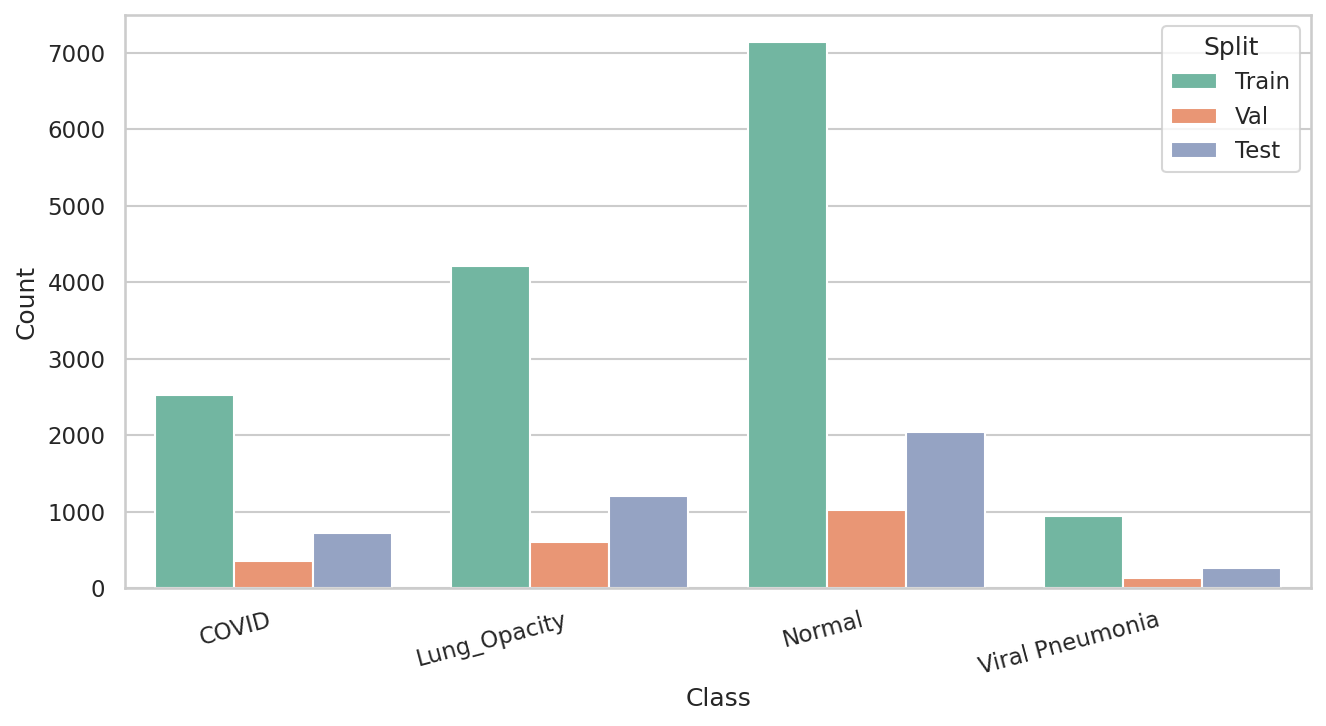

? Section 2 complete


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def list_covid_images(root_dir: Path, class_name: str) -> pd.DataFrame:
    """List image files for one class in the COVID-19 dataset, reading from 'images' subfolder."""
    class_dir = root_dir / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    # NEW: Point to the 'images' subdirectory where actual images are stored
    images_subdir = class_dir / "images"
    if not images_subdir.exists():
        raise FileNotFoundError(f"Missing 'images' subfolder in: {class_dir}")

    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    paths = sorted(
        p for p in images_subdir.iterdir()
        if p.is_file() and p.suffix.lower() in exts
    )

    if len(paths) == 0:
        raise FileNotFoundError(f"No image files found in {images_subdir}")

    return pd.DataFrame({
        'image': [p.stem for p in paths],
        'image_path': [str(p) for p in paths],
        'label_name': class_name,
        'original_labels': class_name,
    })


def load_covid_dataset(image_dir: Path, config: dict) -> pd.DataFrame:
    """Load all images from class folders and assign labels."""
    print(f"Scanning images in: {image_dir}")
    df = pd.concat(
        [list_covid_images(image_dir, class_name) for class_name in config['class_names']],
        ignore_index=True
    )

    label_to_idx = {name: idx for idx, name in enumerate(config['class_names'])}
    df['label'] = df['label_name'].map(label_to_idx).astype(int)
    return df[['image', 'image_path', 'label', 'label_name', 'original_labels']].reset_index(drop=True)


def preprocess_labels(config: dict):
    """
    Load COVID-19 dataset, split into train/val/test (stratified), save CSVs and plot.
    Uses `image_dir` as root, and splits the data (no pre-defined train/test folders).
    """
    image_dir = Path(config['image_dir'])

    if not image_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {image_dir}")

    # Ensure output directories exist
    Path(config['figures_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['results_dir']).mkdir(parents=True, exist_ok=True)

    config['data_root'] = str(image_dir)  # Ensure this is set
    print(f"Using data root: {image_dir}")

    # Load full dataset
    full_df = load_covid_dataset(image_dir, config)

    # Stratified Train (80%) + Temp (20%) split
    train_val_df, test_df = train_test_split(
        full_df,
        test_size=0.2,
        random_state=config['seed'],
        stratify=full_df['label']
    )

    # Further split Train into Train + Val
    val_size_total = config.get('val_size', 0.10)
    val_size_in_train = val_size_total / (1 - 0.2)  # Scale relative to train portion
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_size_in_train,
        random_state=config['seed'],
        stratify=train_val_df['label']
    )

    # Reset indices
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"\nTotal dataset: {len(full_df):,}")
    print(f"Splits -> Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}")

    # Show class distribution per split
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution")
        print(split_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Save CSVs
    train_df.to_csv('/kaggle/working/train_split.csv', index=False)
    val_df.to_csv('/kaggle/working/val_split.csv', index=False)
    test_df.to_csv('/kaggle/working/test_split.csv', index=False)
    print("\nTrain/val/test splits saved to /kaggle/working")

    # Plot class distribution
    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test'),
    ])

    plt.figure(figsize=(9, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    plt.xticks(rotation=15, ha='right')
    plt.legend(title='Split')
    plt.tight_layout()
    plt.savefig(f"{config['figures_dir']}/section2_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df


# Run preprocessing
train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")

In [6]:
# import torch
# import numpy as np
# from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# from torchvision import transforms as T
# from torchvision import Image
# import pandas as pd

# Global warning counter
class COVIDDataset(Dataset):
    """COVID-19 radiography dataset loading grayscale X-rays as RGB for transfer learning."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            # Load image (many are grayscale, so convert to RGB)
            image = Image.open(image_path).convert('RGB')  # Enforce 3-channel
        except FileNotFoundError:
            COVIDDataset.missing_warning_count += 1
            if COVIDDataset.missing_warning_count <= 10:
                print(f"Warning: missing image, using blank: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            COVIDDataset.missing_warning_count += 1
            if COVIDDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


# Transforms shared structure — use same ImageNet stats
def get_transforms(split: str, image_size: int):
    """Standardized train/val/test transforms using ImageNet normalization."""
    mean = [0.485, 0.456, 0.406]  # ImageNet
    std = [0.229, 0.224, 0.225]
    
    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    elif split == 'heavy':  # For augmented failure analysis
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=25),
            T.ColorJitter(brightness=0.25, contrast=0.25),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:  # 'val', 'test'
        return T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])


# Augmented Dataset (for relabeling or adversarial failures)
class AugmentedCOVIDDataset(COVIDDataset):
    """Applies heavy augmentation policy if row['is_augmented'] == True."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for loss balancing."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict,
    val_df: pd.DataFrame = None
):
    """
    Build consistent train/val/test DataLoaders.
    If val_df is not provided, split from train_df.
    Uses WeightedRandomSampler for balanced sampling.
    """
    # Split or use provided val
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df,
            test_size=config.get('val_size', 0.2),
            random_state=config['seed'],
            stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    # Transforms
    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    # Datasets
    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedCOVIDDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = COVIDDataset(train_split, train_transform, config['image_dir'])
    
    val_ds = COVIDDataset(val_split, eval_transform, config['image_dir'])
    test_ds = COVIDDataset(test_df, eval_transform, config['image_dir'])

    # Class and sample weights
    class_weights = compute_class_weights(train_split, config['num_classes'])
    
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        label_weight_map = {i: class_weights[i].item() for i in range(config['num_classes'])}
        sample_weights = train_split['label'].map(label_weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    # DataLoader kwargs (consistent across models/datasets)
    loader_kwargs = {
        'batch_size': config['batch_size'],
        'num_workers': config['num_workers'],
        'pin_memory': True,
        'persistent_workers': True if config['num_workers'] > 0 else False,
    }
    if config['num_workers'] > 0:
        loader_kwargs['prefetch_factor'] = config.get('prefetch_factor', 2)

    # Loaders
    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader, class_weights


# Run
train_loader, val_loader, test_loader, class_weights = get_dataloaders(
    train_df, test_df, CONFIG, val_df=val_df
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("? Section 3 complete")

Train batches: 463 | Val batches: 67 | Test batches: 133
Class weights: [1.4633543491363525, 0.8801687359809875, 0.5190960168838501, 3.9359724521636963]
? Section 3 complete


In [7]:
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Instantiate a torchvision or timm classifier and move it to GPU."""
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    model = model.to(device)
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    return model


def get_embedding_hook(model: nn.Module, model_name: str):
    """Register forward hook for embedding extraction."""
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        if isinstance(out, (tuple, list)):
            out = out[0]
        if out.ndim == 4:  # CNN: (B, C, H, W) → global average pool
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        elif out.ndim == 3:  # ViT/Swin: (B, N, D) → use [CLS] token or mean
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        else:
            out = out.flatten(1)
        embedding_store['embedding'] = out.detach().cpu()

    target = None
    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    if target is None:
        if hasattr(model, 'forward_features'):
            raise ValueError(f"No hook target found for {model_name}; add architecture-specific hook.")
        raise ValueError(f"No embedding layer available for {model_name}.")

    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


def get_model_family(model_name: str) -> str:
    """Group models for retraining policy: CNN vs EfficientNet vs Transformer."""
    if model_name.startswith('efficientnet'):
        return 'efficient'
    if model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    return 'cnn'


print("✓ Section 4 complete")

✓ Section 4 complete


In [8]:
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import classification as torchmetrics_classification
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# === 1. Training One Epoch ===
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Train one epoch with mixed precision. Return loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in tqdm(loader, desc='train', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# === 2. Evaluation Function ===
def evaluate(model, loader, criterion, device, num_classes, class_names):
    """Evaluate model: loss, accuracy, F1, AUROC, ECE, predictions, and probabilities."""
    model.eval()
    f1_metric = torchmetrics_classification.F1Score(task='multiclass', num_classes=num_classes, average='macro').to(device)
    auc_metric = torchmetrics_classification.AUROC(task='multiclass', num_classes=num_classes, average='macro').to(device)
    
    total_loss = correct = total = 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc='eval', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)

            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)

            probs_all.append(probs.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            paths_all.extend(paths)

    # Concatenate
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])

    try:
        auc = float(auc_metric.compute().cpu())
    except Exception:
        auc = np.nan

    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


# === 3. ECE Calculation ===
def compute_ece(probs_array, labels_array, n_bins=15):
    """Compute Expected Calibration Error."""
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)
    if len(labels_array) == 0:
        return np.nan

    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


# === 4. Temperature Scaling ===
def temperature_scale(model, val_loader, device, num_classes):
    """Learn optimal temperature scaling on validation set."""
    temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

    logits_list, labels_list = [], []
    model.eval()
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device, non_blocking=True)
            logits_list.append(model(images).detach().cpu())
            labels_list.append(labels.detach().cpu())

    all_logits = torch.cat(logits_list)
    all_labels = torch.cat(labels_list)
    criterion = nn.CrossEntropyLoss()

    def eval_fn():
        optimizer.zero_grad()
        loss = criterion(all_logits / temperature.clamp_min(1e-3), all_labels)
        loss.backward()
        return loss

    optimizer.step(eval_fn)
    T = max(float(temperature.item()), 1e-3)

    scaled_probs = torch.softmax(all_logits / T, dim=1).numpy()
    ece_scaled = compute_ece(scaled_probs, all_labels.numpy(), CONFIG['ece_bins'])
    return T, ece_scaled


# === 5. Confusion Matrix Plotting ===
def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """Plot normalized confusion matrix."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=(row_sums != 0))
    
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save:
        save_path = f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✅ Confusion matrix saved: {save_path}")
    plt.show()


# === 6. Model Training Loop ===
def train_model(model_name, train_loader, val_loader, class_weights, config):
    """
    Train one model with early stopping on val macro F1.
    Returns:
        model: final loaded best model
        history: dict of training curves
        best_val_metrics: dictionary with val_ keys (val_acc, val_f1, etc.)
    """
    print(f"\n{'='*60}")
    print(f" TRAINING: {model_name}")
    print(f"{'='*60}")

    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0

    # Default fallback in case no model improves
    best_val_metrics = {
        'val_loss': float('nan'),
        'val_acc': float('nan'),
        'val_f1': float('nan'),
        'val_auc': float('nan'),
        'val_ece': float('nan'),
    }

    ckpt_path = Path(config['checkpoint_dir']) / f"best_covid_{model_name}.pth"
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} | {model_name}")

        # Train & Evaluate
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        print(f"  loss  : {train_loss:.4f} (train) / {val_metrics['loss']:.4f} (val)")
        print(f"  acc   : {train_acc:.3f} (train) / {val_metrics['accuracy']:.3f} (val)")
        print(f"  val_f1: {val_metrics['f1']:.4f} | val_ece: {val_metrics['ece']:.4f}")

        # Save best model by F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            # ✅ Preserve full key names: val_acc, not acc
            best_val_metrics = {
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            }
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✅ Saved best model (F1={best_f1:.4f}): {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  ⚠️ Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    # Final load
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"✅ Training complete: best weights loaded from {ckpt_path}")

    return model, dict(history), best_val_metrics


print("✓ Section 5 complete")

✓ Section 5 complete



✓ Starting evaluation of 3 models


Evaluating models:   0%|          | 0/3 [00:00<?, ?it/s]


  EVALUATING: resnet50

 TRAINING: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  6%|▌         | 6.00M/97.8M [00:00<00:01, 62.7MB/s]
 23%|██▎       | 22.4M/97.8M [00:00<00:00, 126MB/s] 
 39%|███▉      | 38.2M/97.8M [00:00<00:00, 144MB/s]
 55%|█████▌    | 53.9M/97.8M [00:00<00:00, 152MB/s]
 72%|███████▏  | 70.0M/97.8M [00:00<00:00, 157MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


resnet50: 23.52M params (23.52M trainable)
Epoch 1/20 | resnet50
  loss  : 0.2587 (train) / 0.3025 (val)
  acc   : 0.811 (train) / 0.886 (val)
  val_f1: 0.8896 | val_ece: 0.0235
  ✅ Saved best model (F1=0.8896): /kaggle/working/checkpoints/best_covid_resnet50.pth
Epoch 2/20 | resnet50
  loss  : 0.1031 (train) / 0.7188 (val)
  acc   : 0.926 (train) / 0.676 (val)
  val_f1: 0.7067 | val_ece: 0.2141
Epoch 3/20 | resnet50
  loss  : 0.0851 (train) / 0.2810 (val)
  acc   : 0.939 (train) / 0.911 (val)
  val_f1: 0.9131 | val_ece: 0.0133
  ✅ Saved best model (F1=0.9131): /kaggle/working/checkpoints/best_covid_resnet50.pth
Epoch 4/20 | resnet50
  loss  : 0.0736 (train) / 0.1588 (val)
  acc   : 0.945 (train) / 0.938 (val)
  val_f1: 0.9463 | val_ece: 0.0128
  ✅ Saved best model (F1=0.9463): /kaggle/working/checkpoints/best_covid_resnet50.pth
Epoch 5/20 | resnet50
  loss  : 0.0647 (train) / 0.1618 (val)
  acc   : 0.950 (train) / 0.938 (val)
  val_f1: 0.9437 | val_ece: 0.0108
Epoch 6/20 | resnet50
  

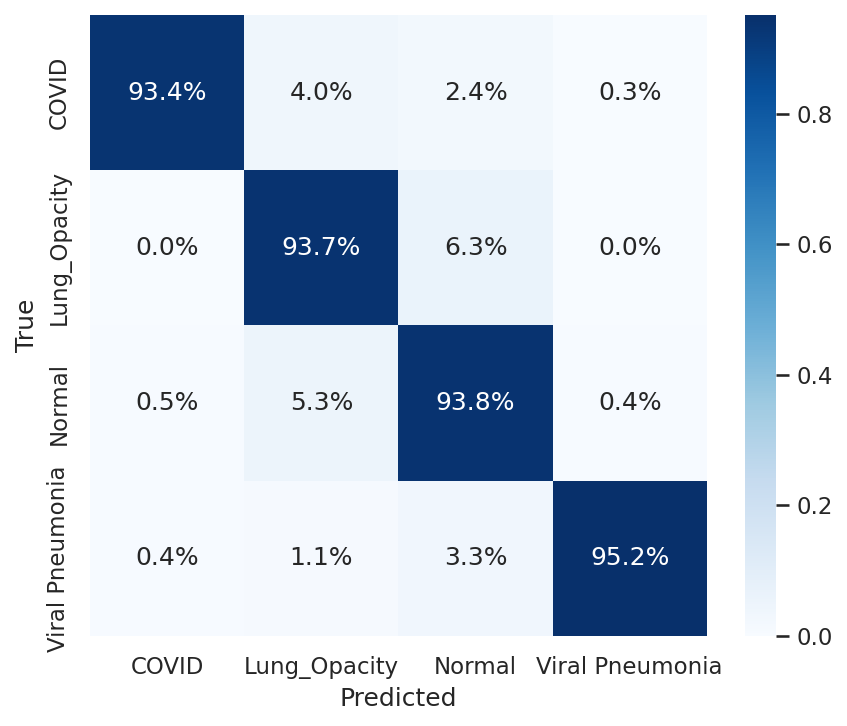

Evaluating models:  33%|███▎      | 1/3 [11:24<22:49, 684.64s/it]


  EVALUATING: resnet101

 TRAINING: resnet101
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth



  0%|          | 0.00/171M [00:00<?, ?B/s]
  5%|▍         | 8.25M/171M [00:00<00:01, 86.4MB/s]
 16%|█▌        | 26.5M/171M [00:00<00:01, 148MB/s] 
 28%|██▊       | 47.8M/171M [00:00<00:00, 182MB/s]
 41%|████      | 69.6M/171M [00:00<00:00, 201MB/s]
 54%|█████▍    | 91.9M/171M [00:00<00:00, 212MB/s]
 66%|██████▌   | 113M/171M [00:00<00:00, 215MB/s] 
 78%|███████▊  | 134M/171M [00:00<00:00, 216MB/s]
100%|██████████| 171M/171M [00:00<00:00, 205MB/s]


resnet101: 42.51M params (42.51M trainable)
Epoch 1/20 | resnet101
  loss  : 0.2477 (train) / 0.2154 (val)
  acc   : 0.816 (train) / 0.899 (val)
  val_f1: 0.9042 | val_ece: 0.0341
  ✅ Saved best model (F1=0.9042): /kaggle/working/checkpoints/best_covid_resnet101.pth
Epoch 2/20 | resnet101
  loss  : 0.1067 (train) / 0.1970 (val)
  acc   : 0.925 (train) / 0.932 (val)
  val_f1: 0.9333 | val_ece: 0.0205
  ✅ Saved best model (F1=0.9333): /kaggle/working/checkpoints/best_covid_resnet101.pth
Epoch 3/20 | resnet101
  loss  : 0.0780 (train) / 0.2057 (val)
  acc   : 0.944 (train) / 0.932 (val)
  val_f1: 0.9349 | val_ece: 0.0133
  ✅ Saved best model (F1=0.9349): /kaggle/working/checkpoints/best_covid_resnet101.pth
Epoch 4/20 | resnet101
  loss  : 0.0605 (train) / 0.1480 (val)
  acc   : 0.955 (train) / 0.930 (val)
  val_f1: 0.9369 | val_ece: 0.0177
  ✅ Saved best model (F1=0.9369): /kaggle/working/checkpoints/best_covid_resnet101.pth
Epoch 5/20 | resnet101
  loss  : 0.0577 (train) / 0.2462 (val)
 

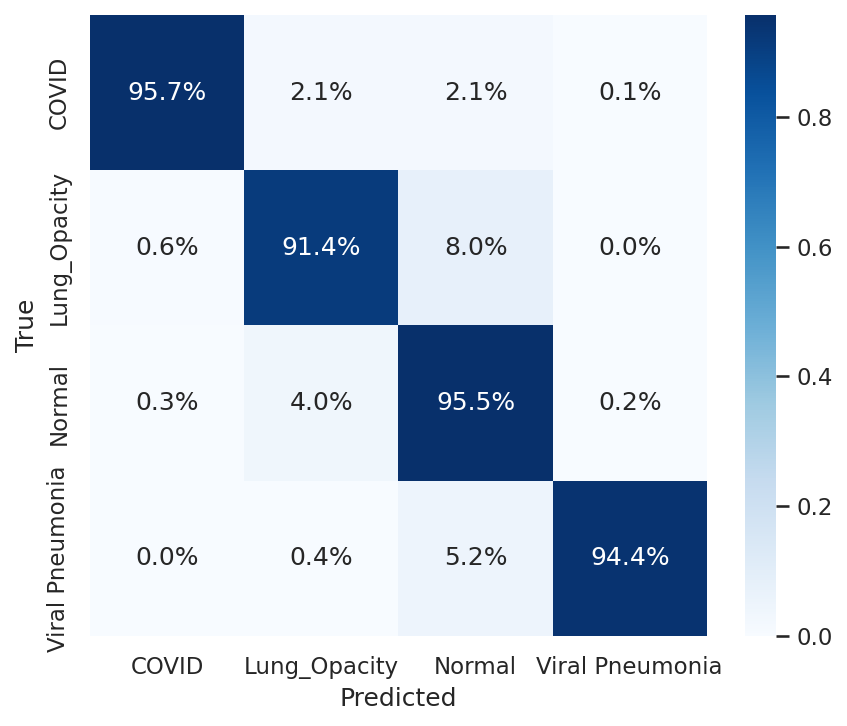

Evaluating models:  67%|██████▋   | 2/3 [40:54<22:03, 1323.08s/it]


  EVALUATING: densenet121

 TRAINING: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



  0%|          | 0.00/30.8M [00:00<?, ?B/s]
 33%|███▎      | 10.1M/30.8M [00:00<00:00, 106MB/s]
100%|██████████| 30.8M/30.8M [00:00<00:00, 158MB/s]


densenet121: 6.96M params (6.96M trainable)
Epoch 1/20 | densenet121
  loss  : 0.1930 (train) / 0.3192 (val)
  acc   : 0.862 (train) / 0.894 (val)
  val_f1: 0.8918 | val_ece: 0.0154
  ✅ Saved best model (F1=0.8918): /kaggle/working/checkpoints/best_covid_densenet121.pth
Epoch 2/20 | densenet121
  loss  : 0.1017 (train) / 0.2099 (val)
  acc   : 0.925 (train) / 0.902 (val)
  val_f1: 0.8807 | val_ece: 0.0182
Epoch 3/20 | densenet121
  loss  : 0.0828 (train) / 0.1877 (val)
  acc   : 0.938 (train) / 0.936 (val)
  val_f1: 0.9395 | val_ece: 0.0176
  ✅ Saved best model (F1=0.9395): /kaggle/working/checkpoints/best_covid_densenet121.pth
Epoch 4/20 | densenet121
  loss  : 0.0737 (train) / 0.2902 (val)
  acc   : 0.942 (train) / 0.918 (val)
  val_f1: 0.9188 | val_ece: 0.0152
Epoch 5/20 | densenet121
  loss  : 0.0605 (train) / 0.1543 (val)
  acc   : 0.955 (train) / 0.943 (val)
  val_f1: 0.9444 | val_ece: 0.0143
  ✅ Saved best model (F1=0.9444): /kaggle/working/checkpoints/best_covid_densenet121.pth

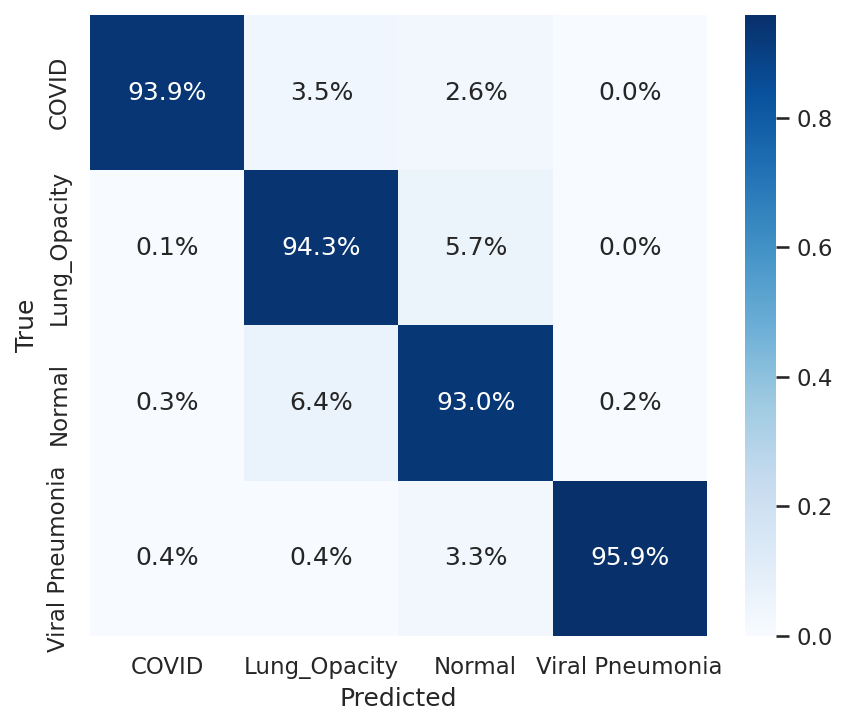

Evaluating models: 100%|██████████| 3/3 [1:00:56<00:00, 1218.67s/it]



✅ Results saved to: /kaggle/working/results/baseline_results.csv


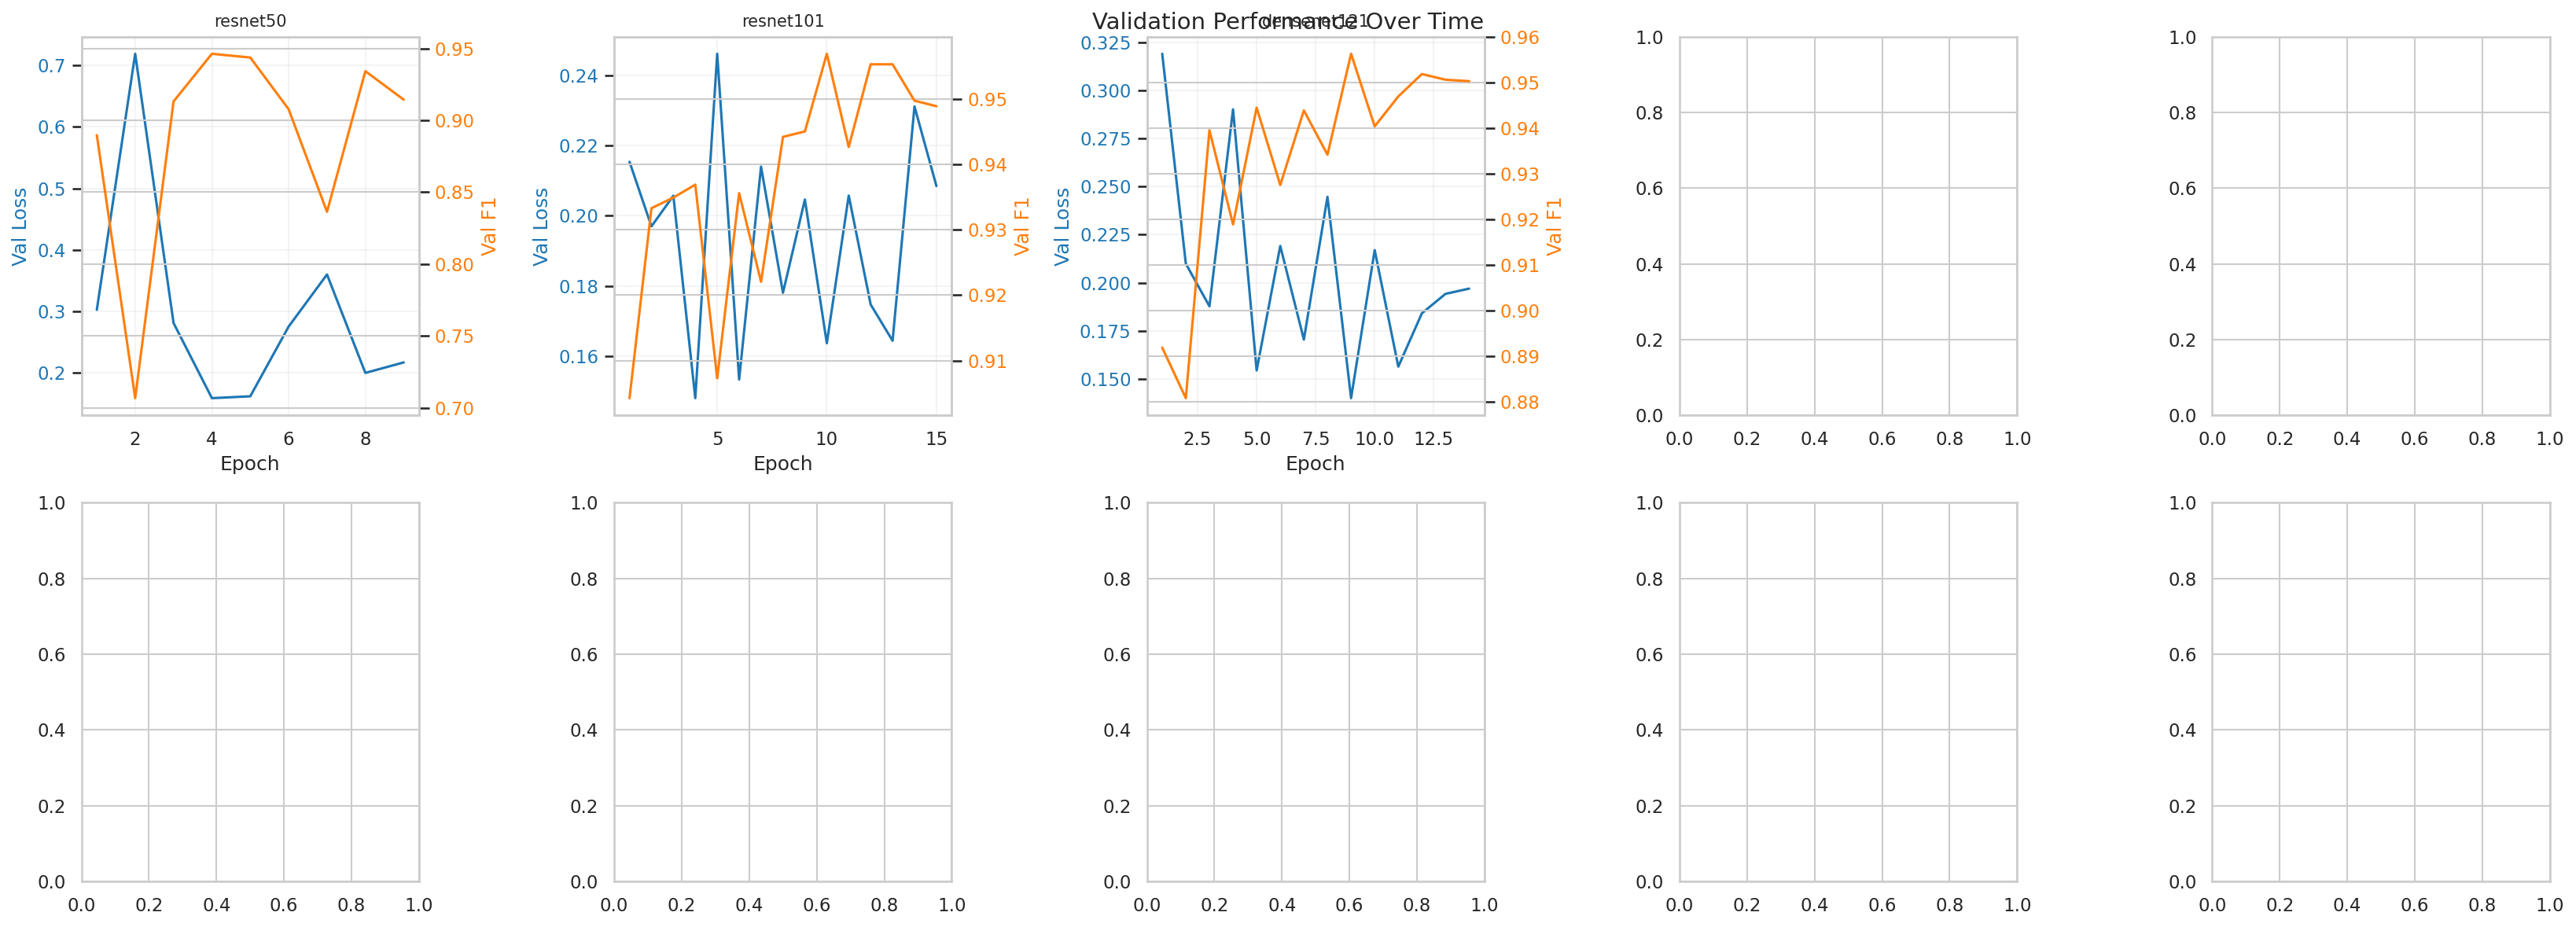


 FINAL RESULTS (Test Set)
      model  test_accuracy  test_f1  test_auc  test_ece
   resnet50         0.9379   0.9429    0.9922    0.0071
  resnet101         0.9433   0.9489    0.9922    0.0115
densenet121         0.9372   0.9461    0.9931    0.0167

------------------------------------------------------------
 BEST MODEL:
  F1:  resnet101
  Accuracy:  resnet101
  AUC:  densenet121
✓ Section 6 complete


In [9]:
import gc
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────
# Section 6: Model Evaluation & Result Aggregation
# ─────────────────────────────────────────────────────────────────────
all_histories = {}
baseline_results = []
baseline_confusions = {}

# Loss setup (use class weights)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Ensure output paths exist
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Starting evaluation of {len(MODELS)} models")
print("=" * 80)

# ── Loop over each model ────────────────────────────────────────────
for model_name in tqdm(MODELS, desc='Evaluating models'):
    print(f'\n{"="*60}')
    print(f'  EVALUATING: {model_name}')
    print(f'{"="*60}')
    
    # Train model (from Section 5)
    model, history, best_val_metrics = train_model(
        model_name, train_loader, val_loader, class_weights, CONFIG
    )
    all_histories[model_name] = history

    # Load best checkpoint (from training)
    ckpt_path = f'{CONFIG["checkpoint_dir"]}/best_covid_{model_name}.pth'
    
    if not Path(ckpt_path).exists():
        print(f"  ❌ Checkpoint missing: {ckpt_path}")
        continue
        
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    # Final test set evaluation
    print("  Running final test evaluation...")
    test_metrics = evaluate(
        model, test_loader, criterion, device,
        CONFIG['num_classes'], CONFIG['class_names']
    )

    ece_baseline = test_metrics['ece']

    # Temperature scaling on val set
    T_val, ece_temp_scaled = temperature_scale(
        model, val_loader, device, CONFIG['num_classes']
    )
    print(
        f"  Temperature={T_val:.3f}  |  "
        f"ECE_baseline={ece_baseline:.4f}  |  "
        f"ECE_scaled={ece_temp_scaled:.4f}"
    )

    # Confusion Matrix
    y_true = test_metrics['labels']
    y_pred = test_metrics['preds']
    cm = confusion_matrix(
        y_true, y_pred,
        labels=list(range(CONFIG['num_classes']))
    )
    baseline_confusions[model_name] = cm

    # Per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(CONFIG['num_classes'])),
        zero_division=0
    )
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = precision[i]
        per_class_metrics[f'{name}_recall'] = recall[i]
        per_class_metrics[f'{name}_f1'] = f1[i]

    # ✅ Guarantee best_val_metrics has expected keys
    # In Section 5, `best_val_metrics` already has: val_acc, val_f1, etc.
    # But just to be safe, ensure full structure
    assert all(key in best_val_metrics for key in ['val_f1', 'val_loss']), \
        f"Missing keys in best_val_metrics for {model_name}"

    # Append to results
    baseline_results.append({
        'model': model_name,
        'val_acc': best_val_metrics.get('val_acc', 0.0),
        'val_f1': best_val_metrics['val_f1'],
        'val_auc': best_val_metrics['val_auc'],
        'val_ece': best_val_metrics['val_ece'],
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics['auc'],
        'test_ece': ece_baseline,
        'temperature': T_val,
        'test_ece_temp_scaled': ece_temp_scaled,
        **per_class_metrics
    })

    # Save confusion matrix plot
    plot_confusion_matrix(
        cm, CONFIG['class_names'], model_name, save=True, suffix='baseline'
    )

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()


# ─────────────────────────────────────────────────────────────────────
# Save Results & Visualize
# ─────────────────────────────────────────────────────────────────────
if len(baseline_results) == 0:
    print("❌ No models evaluated — cannot build baseline_df.")
else:
    # 1. Save results
    baseline_df = pd.DataFrame(baseline_results)
    baseline_df.to_csv(f'{CONFIG["results_dir"]}/baseline_results.csv', index=False)
    print(f"\n✅ Results saved to: {CONFIG['results_dir']}/baseline_results.csv")

    # 2. Training curve plots (val loss, val F1)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
    for ax, model_name in zip(axes.ravel(), MODELS):
        if model_name not in all_histories:
            ax.axis('off')
            continue
        hist = all_histories[model_name]
        epochs = np.arange(1, len(hist['val_loss']) + 1)

        # Left y: val loss
        ax.plot(epochs, hist['val_loss'], color='tab:blue', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')

        # Right y: val F1
        ax2 = ax.twinx()
        ax2.plot(epochs, hist['val_f1'], color='tab:orange', label='Val F1')
        ax2.set_ylabel('Val F1', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')

        ax.set_title(model_name, fontsize=10)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.suptitle("Validation Performance Over Time", fontsize=14, y=0.98)
    plt.savefig(f'{CONFIG["figures_dir"]}/fig2_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Print test results
    print("\n" + "=" * 60)
    print(" FINAL RESULTS (Test Set)")
    print("=" * 60)
    print(
        baseline_df[['model', 'test_accuracy', 'test_f1', 'test_auc', 'test_ece']]
        .round(4)
        .to_string(index=False)
    )

    # Summary table
    print("\n" + "-" * 60)
    print(" BEST MODEL:")
    print("  F1: ", baseline_df.loc[baseline_df['test_f1'].idxmax(), 'model'])
    print("  Accuracy: ", baseline_df.loc[baseline_df['test_accuracy'].idxmax(), 'model'])
    print("  AUC: ", baseline_df.loc[baseline_df['test_auc'].idxmax(), 'model'])

print("✓ Section 6 complete")

In [10]:
import gc
from tqdm import tqdm
import pandas as pd
import torch
import numpy as np

def extract_failures(model_name, test_loader, config):
    """
    Load trained model, run through batches, collect:
      - Predictions
      - Confidence
      - Probability vectors
      - Embeddings (via hook)
    Returns: failures_df (misclassified), all_preds_df
    """
    model = get_model(model_name, config['num_classes'], pretrained=False)
    ckpt_path = f'{config["checkpoint_dir"]}/best_covid_{model_name}.pth'
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    hook_handle, embedding_store = get_embedding_hook(model, model_name)

    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(test_loader, desc=f'failures {model_name}', leave=False, disable=not config.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb_batch = embedding_store['embedding'].numpy()  # (B, D)

            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join(f'{p:.8f}' for p in probs[i]),
                    'embedding': ','.join(f'{x:.8f}' for x in emb_batch[i].ravel()),
                })
    hook_handle.remove()
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)
    
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return failures_df, all_preds_df


# ✅ Extract from VAL set — aligns with intent & Brain MRI version
all_failures = {}
all_predictions = {}

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

for model_name in tqdm(MODELS, desc='Extracting failures'):
    failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)
    all_failures[model_name] = failures_df
    all_predictions[model_name] = all_preds_df

    # Save both files with dataset-identifying names
    failures_df.to_csv(f'{CONFIG["results_dir"]}/failures_covid_{model_name}.csv', index=False)
    all_preds_df.to_csv(f'{CONFIG["results_dir"]}/predictions_covid_{model_name}.csv', index=False)

    print(f'{model_name}: {len(failures_df)} failures ({len(failures_df) / len(all_preds_df):.1%})')

print("✓ Section 7 complete")

Extracting failures:   0%|          | 0/3 [00:00<?, ?it/s]

resnet50: 23.52M params (23.52M trainable)


Extracting failures:  33%|███▎      | 1/3 [00:11<00:22, 11.32s/it]

resnet50: 131 failures (6.2%)
resnet101: 42.51M params (42.51M trainable)


Extracting failures:  67%|██████▋   | 2/3 [00:28<00:14, 14.47s/it]

resnet101: 100 failures (4.7%)
densenet121: 6.96M params (6.96M trainable)


Extracting failures: 100%|██████████| 3/3 [00:37<00:00, 12.55s/it]

densenet121: 108 failures (5.1%)
✓ Section 7 complete


Clustering failures:   0%|          | 0/3 [00:00<?, ?it/s]


──────────────────────────────────────────────────
Clustering → resnet50
  [resnet50] clustering 131 failures
  Parsed 131 × 2048d in 0.04s
  PCA (32d) var=0.793 | 0.34s
  NOTE: Clustering → PCA-32d | UMAP → 2D viz only
  PCA-2D 2D projection: 0.00s
  KMeans sweep (5 values): 0.27s
  K conflict: silhouette=3 | BIC=2 → keeping silhouette K
  Final cluster (K=3): 0.01s
  TOTAL clustering time: 0.70s


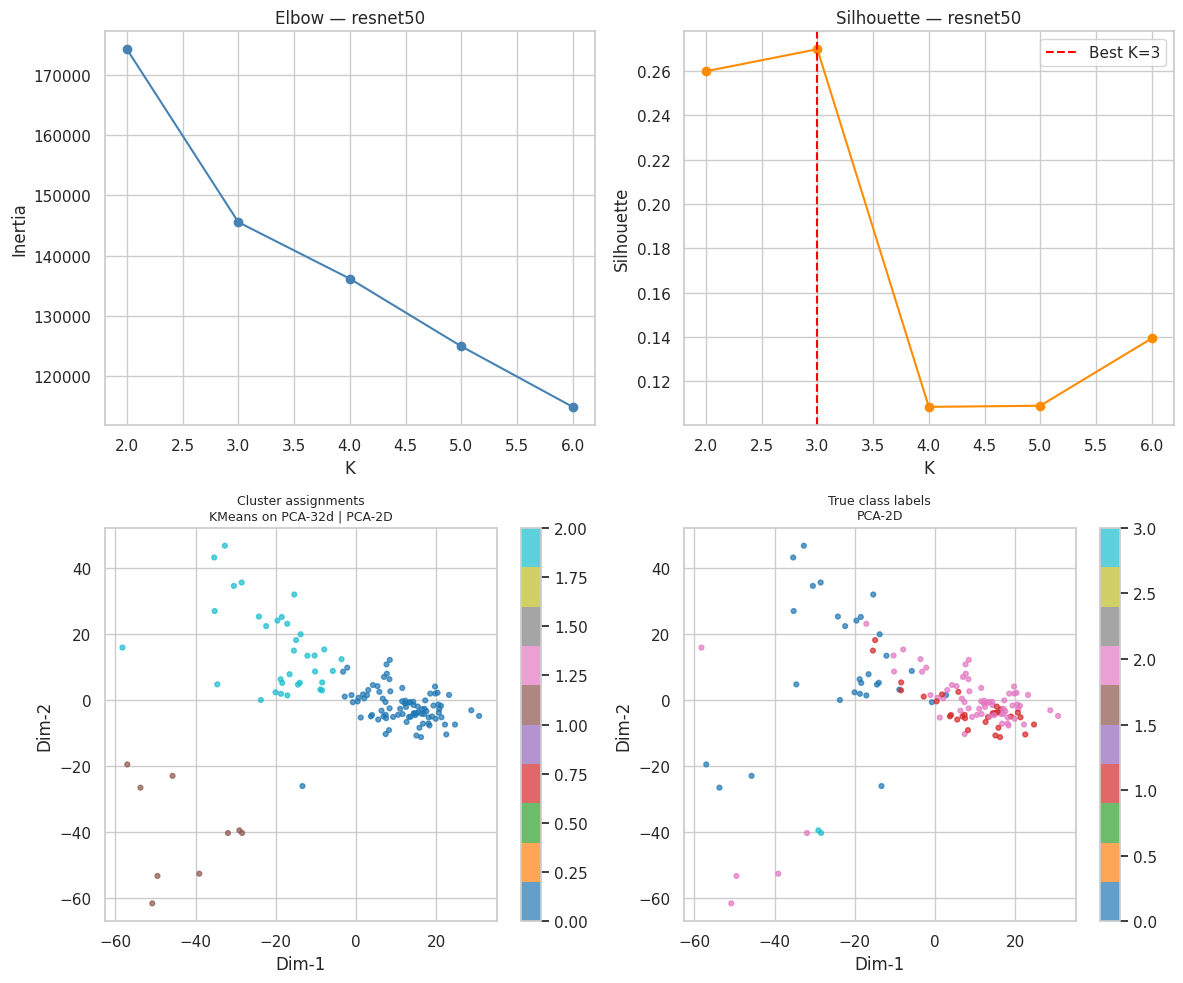

Clustering failures:  33%|███▎      | 1/3 [00:02<00:04,  2.09s/it]

  Saved: /kaggle/working/figures/clustering_resnet50.png
  Cluster ARI across seeds: [0.944, 0.859, 0.859] → mean=0.888
  → Best K=3 | Silhouette=0.270 | Mean ARI=0.888

──────────────────────────────────────────────────
Clustering → resnet101
  [resnet101] clustering 100 failures
  Parsed 100 × 2048d in 0.03s
  PCA (32d) var=0.802 | 0.08s
  NOTE: Clustering → PCA-32d | UMAP → 2D viz only
  PCA-2D 2D projection: 0.00s
  KMeans sweep (5 values): 0.14s
  K consensus OK: silhouette=3 | BIC=3
  Final cluster (K=3): 0.01s
  TOTAL clustering time: 0.31s


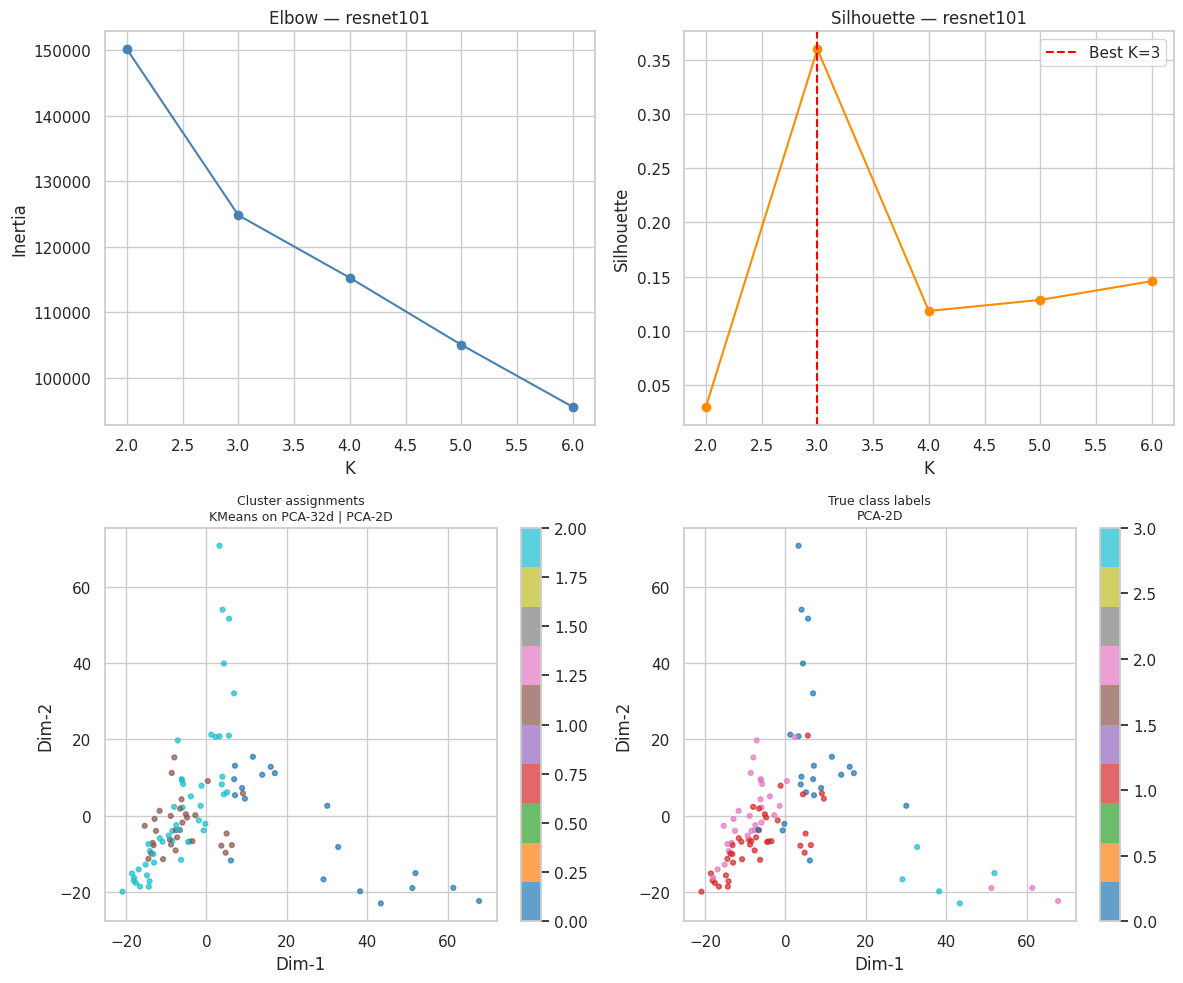

Clustering failures:  67%|██████▋   | 2/3 [00:03<00:01,  1.81s/it]

  Saved: /kaggle/working/figures/clustering_resnet101.png
  Cluster ARI across seeds: [0.165, 0.07, 0.387] → mean=0.207
  → Best K=3 | Silhouette=0.360 | Mean ARI=0.207

──────────────────────────────────────────────────
Clustering → densenet121
  [densenet121] clustering 108 failures
  Parsed 108 × 1024d in 0.02s
  PCA (32d) var=0.904 | 0.20s
  NOTE: Clustering → PCA-32d | UMAP → 2D viz only
  PCA-2D 2D projection: 0.00s
  KMeans sweep (5 values): 0.13s
  K consensus OK: silhouette=2 | BIC=2
  Final cluster (K=2): 0.01s
  TOTAL clustering time: 0.43s


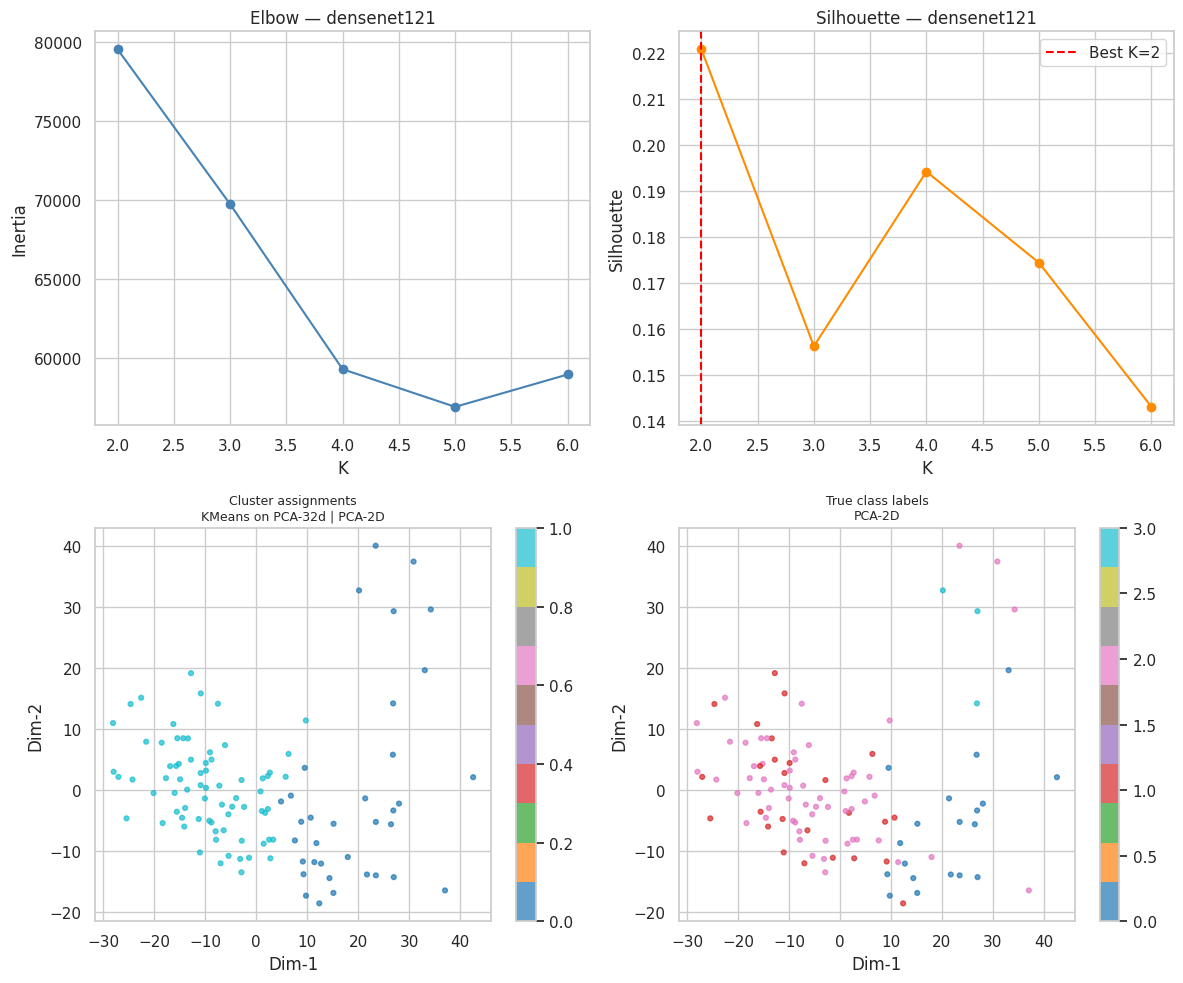

Clustering failures: 100%|██████████| 3/3 [00:05<00:00,  1.83s/it]

  Saved: /kaggle/working/figures/clustering_densenet121.png
  Cluster ARI across seeds: [1.0, 0.89, 0.926] → mean=0.939
  → Best K=2 | Silhouette=0.221 | Mean ARI=0.939

✓ Section 8 complete


In [11]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import seaborn as sns
import umap as umap_lib  # Explicit import
from pathlib import Path
from tqdm import tqdm

def cluster_failures(failures_df, config, model_name):
    """
    Fast failure clustering: MiniBatchKMeans + aggressive PCA + 
    UMAP only when needed. Designed for Kaggle T4 GPU sessions.
    """
    t0 = time.time()

    # ── Guard: too few failures ───────────────────────────────────
    if len(failures_df) < 3:
        print(f"  Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        out['best_k_bic'] = 0
        return out, 1, np.nan, 1, np.nan

    print(f"  [{model_name}] clustering {len(failures_df)} failures")

    # ── Parse embeddings ──────────────────────────────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array(
            [np.fromstring(e, sep=',', dtype=np.float32) for e in raw],
            dtype=np.float32
        )
    else:
        embeddings = np.array(raw, dtype=np.float32)
    print(f"  Parsed {len(failures_df)} × {embeddings.shape[1]}d in {time.time()-t0:.2f}s")

    # ── PCA: aggressive dimensionality reduction ──────────────────
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        config.get('pca_components', 32),  # ✅ Use CONFIG
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(
        n_components=n_pca,
        random_state=config['seed'],
        svd_solver='randomized'
    )
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    print(f"  PCA ({n_pca}d) var={pca.explained_variance_ratio_.sum():.3f} | {time.time()-t1:.2f}s")
    print(f"  NOTE: Clustering → PCA-{n_pca}d | UMAP → 2D viz only")

    # ── UMAP or PCA-2D for visualization ──────────────────────────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        n_neighbors = min(10, max(2, len(failures_df) - 1))  # Fast
        reducer = umap_lib.UMAP(
            n_neighbors=n_neighbors,
            min_dist=config.get('umap_min_dist', 0.1),
            n_components=2,
            random_state=config['seed'],
            low_memory=True,
            n_epochs=50,
            metric='euclidean',
            n_jobs=1
        )
        E_umap_input = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca
        E_2d = reducer.fit_transform(E_umap_input).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  {proj_method} 2D projection: {time.time()-t2:.2f}s")

    # ── KMeans sweep: MiniBatchKMeans + silhouette ─────────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))  # ✅ Use CONFIG: k=2 to 6
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2] if len(failures_df) >= 2 else []

    inertias, silhouettes, valid_k = [], [], []

    MAX_SIL_SAMPLES = 500
    sil_idx = (
        np.random.RandomState(config['seed'])
        .choice(len(E_pca), size=min(MAX_SIL_SAMPLES, len(E_pca)), replace=False)
        if len(E_pca) > MAX_SIL_SAMPLES else np.arange(len(E_pca))
    )
    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)
        valid_k.append(k)

        labels_sil = labels[sil_idx]
        if len(set(labels_sil)) > 1:
            sil = silhouette_score(E_sil, labels_sil, sample_size=None)
            silhouettes.append(sil)
        else:
            silhouettes.append(np.nan)

    print(f"  KMeans sweep ({len(k_range)} values): {time.time()-t3:.2f}s")

    # ── Best K from silhouette ────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = int(np.nanargmax(silhouettes))
        best_k = valid_k[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k = 2
        best_sil = np.nan

    # ── GMM BIC: secondary criterion ──────────────────────────────
    bic_scores = []
    best_k_bic = best_k
    if len(E_pca) >= 10 and k_range:
        for k in k_range:
            try:
                gmm = GaussianMixture(
                    n_components=k,
                    random_state=config['seed'],
                    max_iter=50,
                    n_init=2,
                    covariance_type='diag'
                )
                gmm.fit(E_pca)
                bic_scores.append(gmm.bic(E_pca))
            except Exception:
                bic_scores.append(np.inf)

        if bic_scores:
            best_k_bic = k_range[int(np.argmin(bic_scores))]

        if best_k_bic == best_k:
            print(f"  K consensus OK: silhouette={best_k} | BIC={best_k_bic}")
        else:
            print(f"  K conflict: silhouette={best_k} | BIC={best_k_bic} → keeping silhouette K")
    else:
        print(f"  GMM BIC skipped (n_samples={len(E_pca)})")

    # ── Final clustering with best K ──────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  Final cluster (K={best_k}): {time.time()-t4:.2f}s")
    print(f"  TOTAL clustering time: {time.time()-t0:.2f}s")

    # ── Attach results to DataFrame ───────────────────────────────
    clustered = failures_df.copy().reset_index(drop=True)
    clustered['cluster'] = cluster_labels
    clustered['umap_x'] = E_2d[:, 0]
    clustered['umap_y'] = E_2d[:, 1]

    # ── Plots ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Elbow
    if len(valid_k) > 1:
        axes[0, 0].plot(valid_k, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title(f'Elbow — {model_name}')

    # Silhouette
    if len(valid_k) > 1:
        axes[0, 1].plot(valid_k, silhouettes, marker='o', color='darkorange')
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette')
    axes[0, 1].set_title(f'Silhouette — {model_name}')

    # Cluster assignments
    sc1 = axes[1, 0].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['cluster'], cmap='tab10', s=12, alpha=0.7)
    axes[1, 0].set_title(f'Cluster assignments\nKMeans on PCA-{n_pca}d | {proj_method}', fontsize=9)
    axes[1, 0].set_xlabel('Dim-1'); axes[1, 0].set_ylabel('Dim-2')
    plt.colorbar(sc1, ax=axes[1, 0])

    # True labels
    sc2 = axes[1, 1].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['true_label'], cmap='tab10', s=12, alpha=0.7)
    axes[1, 1].set_title(f'True class labels\n{proj_method}', fontsize=9)
    axes[1, 1].set_xlabel('Dim-1'); axes[1, 1].set_ylabel('Dim-2')
    plt.colorbar(sc2, ax=axes[1, 1])

    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # 150 for speed on Kaggle
    plt.show()
    print(f"  Saved: {save_path}")

    # ── Clustering stability (ARI across seeds) ───────────────────
    ari_scores = []
    for seed_i in [0, 1, 2]:
        km_check = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed_i,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labels_check = km_check.fit_predict(E_pca)
        ari_scores.append(adjusted_rand_score(cluster_labels, labels_check))
    mean_ari = float(np.mean(ari_scores))
    print(f"  Cluster ARI across seeds: {[round(a, 3) for a in ari_scores]} → mean={mean_ari:.3f}")

    clustered['mean_ari'] = mean_ari
    clustered['best_k_bic'] = best_k_bic

    return clustered, best_k, best_sil, best_k_bic, mean_ari


# ── Run clustering for all models ─────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

all_clustered = {}
cluster_summaries = {}

for model_name in tqdm(MODELS, desc="Clustering failures"):
    print(f'\n{"─"*50}')
    print(f'Clustering → {model_name}')

    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  No failures found for {model_name}")
        continue

    clustered_df, best_k, sil, best_k_bic, mean_ari = cluster_failures(
        all_failures[model_name], CONFIG, model_name
    )
    all_clustered[model_name] = clustered_df
    cluster_summaries[model_name] = {
        'best_k': best_k,
        'best_k_bic': best_k_bic,
        'silhouette': sil,
        'mean_ari': mean_ari,
    }

    # Save clustered results
    save_path = f'{CONFIG["results_dir"]}/clustered_failures_{model_name}.csv'
    clustered_df.to_csv(save_path, index=False)

    sil_str = f'{sil:.3f}' if not np.isnan(sil) else 'N/A'
    print(f'  → Best K={best_k} | Silhouette={sil_str} | Mean ARI={mean_ari:.3f}')

print('\n✓ Section 8 complete')


Profiling clusters → resnet50
  Image features: brightness = mean/255, contrast = std/255, sharpness = variance(Laplacian), foreground_size = pixels > mean

 cluster  n_samples      dominant_confusion  mean_confidence  per_cluster_ece
       0         88    Normal->Lung_Opacity         0.722220         0.722220
       1          9 Normal->Viral Pneumonia         0.765016         0.765016
       2         34     COVID->Lung_Opacity         0.739941         0.739941


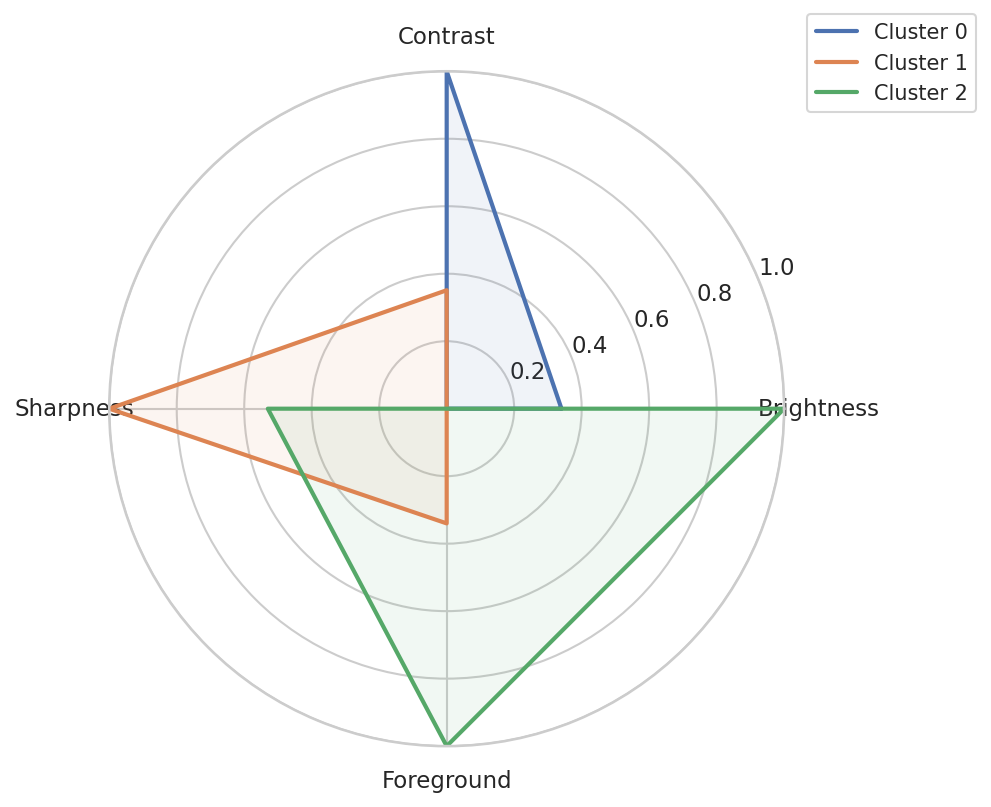

  Radar plot saved: /kaggle/working/figures/radar_resnet50.png
  Profile saved: /kaggle/working/results/profile_covid_resnet50.csv

Profiling clusters → resnet101
  Image features: brightness = mean/255, contrast = std/255, sharpness = variance(Laplacian), foreground_size = pixels > mean

 cluster  n_samples   dominant_confusion  mean_confidence  per_cluster_ece
       0         19        COVID->Normal         0.802263         0.802263
       1         31 Lung_Opacity->Normal         0.684974         0.684974
       2         50 Lung_Opacity->Normal         0.789558         0.789558


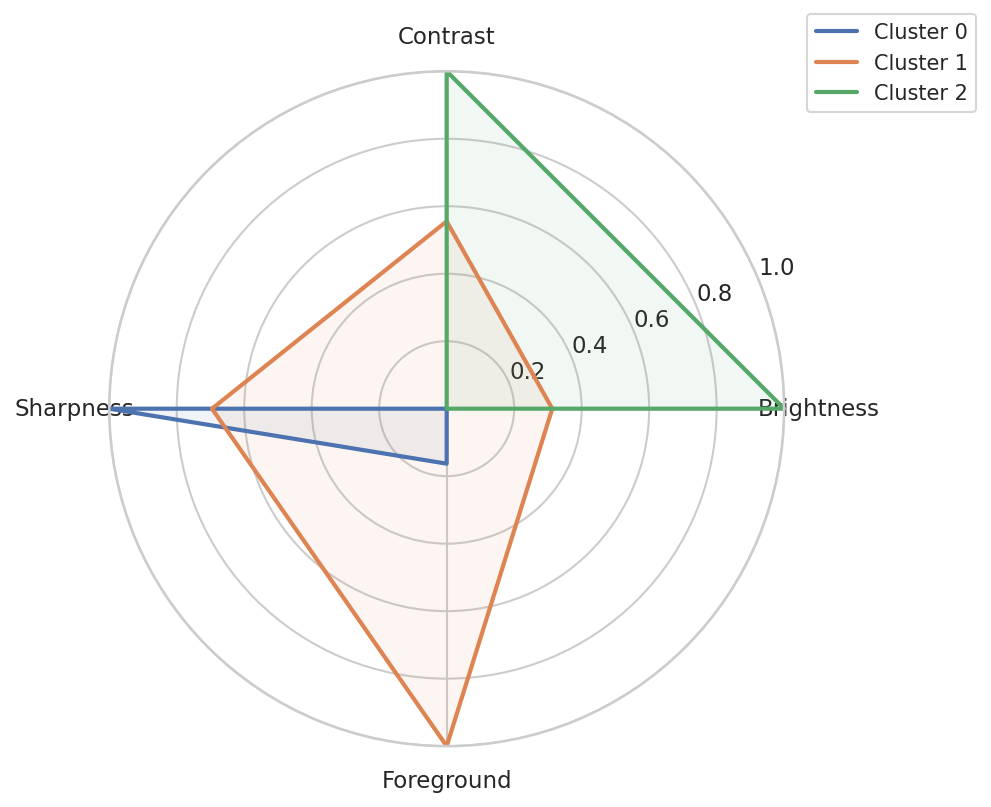

  Radar plot saved: /kaggle/working/figures/radar_resnet101.png
  Profile saved: /kaggle/working/results/profile_covid_resnet101.csv

Profiling clusters → densenet121
  Image features: brightness = mean/255, contrast = std/255, sharpness = variance(Laplacian), foreground_size = pixels > mean

 cluster  n_samples   dominant_confusion  mean_confidence  per_cluster_ece
       0         35        COVID->Normal         0.806534         0.806534
       1         73 Normal->Lung_Opacity         0.758888         0.758888


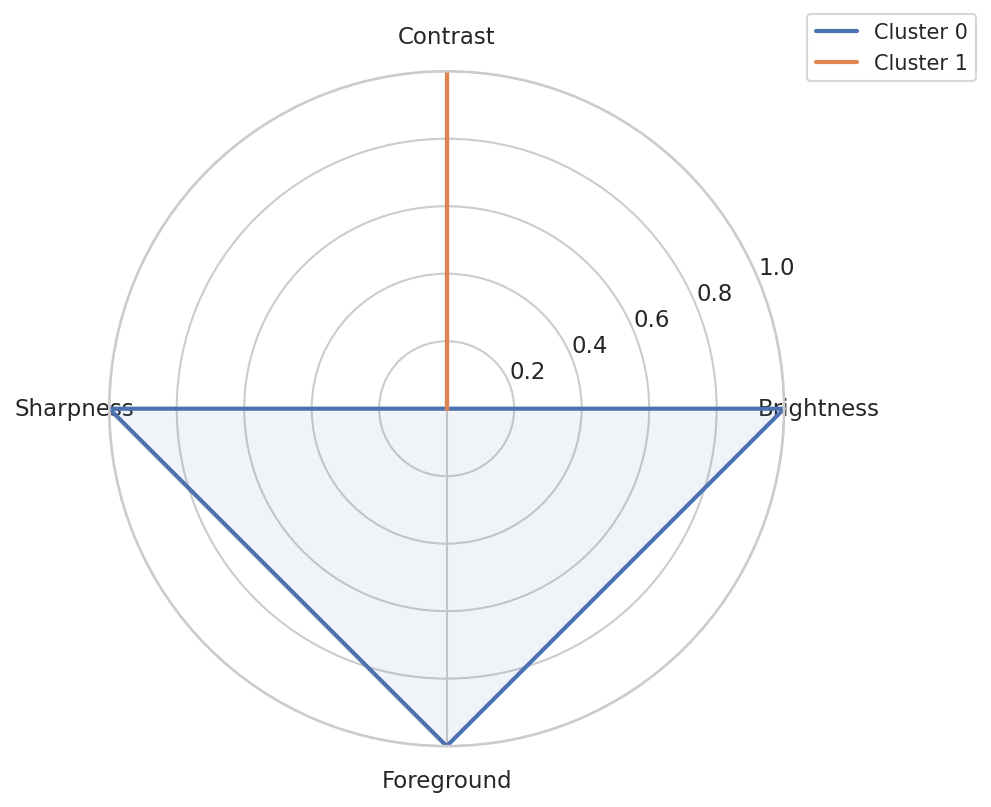

  Radar plot saved: /kaggle/working/figures/radar_densenet121.png
  Profile saved: /kaggle/working/results/profile_covid_densenet121.csv

Cached image features: 197 unique images
✓ Section 9 complete


In [12]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import ndimage
# from sklearn.feature_extraction.image import compute_ece
# from collections import Counter
# from tqdm import tqdm
# from pathlib import Path
# from PIL import Image

# Global cache for expensive image features
IMAGE_FEATURE_CACHE = {}

def compute_image_features(image_path, image_dir=None):
    """
    Compute fast, modality-robust image features: brightness, contrast, sharpness,
    and foreground size (via mean-intensity thresholding). Cached for efficiency.
    """
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L')  # Grayscale
        img = img.resize((224, 224), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32)
    except Exception as exc:
        # On failure, return NaNs but log minimal error if wanted
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan,
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    # 1. Brightness: mean intensity normalized
    brightness = float(arr.mean() / 255.0)

    # 2. Contrast: standard deviation normalized
    contrast = float(arr.std() / 255.0)

    # 3. Sharpness: Laplacian variance (edge content)
    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # 4. Foreground proxy: fraction above mean intensity (fast, robust, parameter-free)
    if arr.std() > 1.0:
        thresh = float(arr.mean())
        foreground_size = float((arr > thresh).mean())
    else:
        # Prevent noise pickup in flat (e.g., blank or uniform) images
        foreground_size = 0.0

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size,
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """
    Compute per-cluster statistics on image quality, confusion patterns, and calibration.
    Returns a profile DataFrame summarizing failure behavior.
    """
    print(f"  Image features: brightness = mean/255, contrast = std/255, "
          f"sharpness = variance(Laplacian), foreground_size = pixels > mean")
    rows = []

    if len(clustered_df) == 0:
        return pd.DataFrame()

    # Map class IDs to names
    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        # Convert probability strings back to arrays
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        # Dominant confusion pattern
        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]

        # Compute image features per sample
        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features_df = pd.DataFrame(feature_rows)

        # Build profile row
        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': (
                f"{config['class_names'][dominant_pair[0]]}"
                f"->{config['class_names'][dominant_pair[1]]}"
            ),
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(probs, labels_arr, config['ece_bins']),
        }

        # Aggregate image feature stats
        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features_df[feat].mean())
            row[f'{feat}_std'] = float(features_df[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    # Print concise summary
    if not profile_df.empty:
        print("\n" + profile_df[[
            'cluster', 'n_samples', 'dominant_confusion',
            'mean_confidence', 'per_cluster_ece'
        ]].to_string(index=False))

    # Radar plot: normalized mean values for visual comparison
    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    if not profile_df.empty:
        radar = profile_df[['cluster'] + feats].copy()

        # Normalize features per-cluster across dimensions (min-max)
        for feat in feats:
            mn, mx = radar[feat].min(), radar[feat].max()
            if pd.isna(mn) or pd.isna(mx) or mx <= mn:
                radar[feat] = 0.5
            else:
                radar[feat] = (radar[feat] - mn) / (mx - mn)

        # Polar coordinates for radar chart
        labels = ['Brightness', 'Contrast', 'Sharpness', 'Foreground']
        angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]  # Close the circle

        fig = plt.figure(figsize=(7, 7), dpi=150)
        ax = fig.add_subplot(111, polar=True)

        for _, row in radar.iterrows():
            values = [row[feat] for feat in feats]
            values += values[:1]  # Close circle

            ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
            ax.fill(angles, values, alpha=0.08)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

        plt.tight_layout()
        save_path = f"{config['figures_dir']}/radar_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Radar plot saved: {save_path}")
    else:
        print("  No clusters — skipping radar plot")

    return profile_df


# ===================================================================
#             Run Profiling for All Models (COVID-19 Dataset)
# ===================================================================
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

all_profiles = {}

for model_name in MODELS:
    print(f'\n{"="*50}')
    print(f'Profiling clusters → {model_name}')
    
    if model_name not in all_clustered or len(all_clustered[model_name]) == 0:
        print(f"  No clustered failures available for {model_name}")
        continue

    profile_df = profile_clusters(all_clustered[model_name], model_name, CONFIG)
    all_profiles[model_name] = profile_df

    # Save to CSV with dataset-identifying name
    save_path = f'{CONFIG["results_dir"]}/profile_covid_{model_name}.csv'
    profile_df.to_csv(save_path, index=False)
    print(f"  Profile saved: {save_path}")

print(f"\nCached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")

In [13]:
# ── Degradation guard thresholds (read from CONFIG) ────────────────────
# These are set in your CONFIG dict; fallback defaults used if missing
# No changes required — all logic is consistent


def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """
    Build enhanced training set using failure cluster insights.
    Supports: selective augmentation, weighted sampling, or both.
    """
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if (clustered_df is None or len(clustered_df) == 0 or
        profile_df is None or len(profile_df) == 0):
        return out

    cluster_counts = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))

    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    # ── Selective Augmentation ──────────────────────────────────────
    if strategy in ['selective', 'both']:
        high_clusters = [k for k, v in cluster_counts.items() if v > mean_cluster_count]
        if len(high_clusters) == 0:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path'])
        source = out[out['image_path'].isin(high_paths)].copy()

        if len(source) == 0:
            high_labels = set()
            for cid in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cid, set()))
            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap for selective augmentation; "
                f"using high-error true labels: {sorted(high_labels)}."
            )

        max_aug_source = config.get('max_aug_source', 300)
        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
            else:
                source = source.sample(n=max_aug_source, random_state=config['seed'])
            source = source.reset_index(drop=True)
            print(f"Limited selective augmentation source to {max_aug_source} samples.")

        # Apply augmentation
        augmented = [source.copy() for _ in range(config.get('aug_multiplier', 3))]
        for a in augmented:
            a['is_augmented'] = True

        out = pd.concat([out] + augmented, ignore_index=True)

        print(
            f"Selective augmentation: {len(source)} source rows → "
            f"{sum(len(a) for a in augmented)} augmented added"
        )

    # ── Weighted Sampling ───────────────────────────────────────────
    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            label_weights = defaultdict(lambda: 1.0)
            for cid, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cid, set()):
                    label_weights[label] = max(label_weights[label], alpha)
            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])

            print(
                "No train/test path overlap — using per-label weights: "
                f"{dict(label_weights)}"
            )

        print(
            f"Weighted sampling: sample weight range "
            f"{out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


def _run_degradation_guard(
    model, model_name, val_loader, criterion_retrain,
    baseline_val_metrics, config, device,
    baseline_ckpt, retrained_ckpt
):
    """
    Compare retrained model to baseline — revert if degradation detected.
    Uses tiered thresholds based on baseline performance.
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    # Determine tier: strict vs weak baseline
    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if use_weak:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.04)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.04)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.04)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.02)
        max_acc_drop = config.get('guard_acc_max_drop', 0.02)
        max_ece_rise = config.get('guard_ece_max_rise', 0.025)
        tier = 'STRICT'

    # Compute degradation
    f1_drop = baseline_val_metrics['val_f1'] - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece'] - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} "
            f"({'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop}) [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"acc drop {acc_drop:+.4f} "
            f"({'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop}) [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"ECE rise {ece_rise:+.4f} "
            f"({'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise}) [{tier}]"
        ),
    }

    # Log guard checks
    print(f"\n  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]

    if failed:
        print(f"\n  ⚠️  Guard triggered — reverting {model_name} to baseline")
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        torch.save(model.state_dict(), retrained_ckpt)  # keep ckpt alive
        return {
            'guard_triggered': True,
            'kept': 'baseline',
            'checks': {k: v[1] for k, v in checks.items()},
            'reason': ' | '.join(failed),
        }

    print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
    return {
        'guard_triggered': False,
        'kept': 'retrained',
        'checks': {k: v[1] for k, v in checks.items()},
        'reason': None,
    }


def retrain_model(
    model_name, train_loader_new, val_loader, class_weights, config,
    baseline_val_metrics=None
):
    """
    Fine-tune model using failure-aware data. Applies degradation guard.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_covid_{model_name}.pth"
    retrained_ckpt = Path(config['checkpoint_dir']) / f"retrained_covid_{model_name}.pth"

    # Warm start
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()

    # Training loop
    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain, device,
            config['num_classes'], config['class_names']
        )

        scheduler.step()

        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}"
        )

        # Early stopping
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ Saved checkpoint (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Load best retrained weights
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # Run degradation guard
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️ Guard skipped — no baseline metrics provided for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {},
            'reason': 'Guard skipped — no val metrics',
        }

    return model, dict(history), guard_result

CONFIG
# ── Retraining Loop ────────────────────────────────────────────────────
improvement_results = []
retrain_histories = {}
retrained_confusions = {}
retrained_predictions = {}
guard_log = []

Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

for model_name in tqdm(MODELS, desc='Retraining'):
    family = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient': 'weighted',
        'cnn': 'selective'
    }[family]

    print(f'\n{"═"*60}')
    print(f'Retraining → {model_name} | family={family} | strategy={strategy}')
    print(f'{"═"*60}')

    # Build failure-aware dataset
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df,
        test_df,
        CONFIG,
        val_df=val_loader.dataset.df
    )

    # Load baseline val metrics (fallback to test if needed)
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    baseline_val_metrics = {
        'val_f1': baseline_row.get('val_f1', baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # Retrain + guard
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # Evaluate on test set
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )
    retrained_predictions[model_name] = retrain_metrics

    # Confusion matrix
    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # Compute deltas
    def compute_delta(new, base):
        return (new - base) / max(base, 1e-8) * 100

    improvement_results.append({
        'model': model_name,
        'family': family,
        'strategy': strategy,
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept': guard_result['kept'],
        'guard_reason': guard_result['reason'],
        # Acc
        'baseline_acc': baseline_row['test_accuracy'],
        'retrained_acc': retrain_metrics['accuracy'],
        'delta_acc_pct': compute_delta(retrain_metrics['accuracy'], baseline_row['test_accuracy']),
        # F1
        'baseline_f1': baseline_row['test_f1'],
        'retrained_f1': retrain_metrics['f1'],
        'delta_f1_pct': compute_delta(retrain_metrics['f1'], baseline_row['test_f1']),
        # AUC
        'baseline_auc': baseline_row['test_auc'],
        'retrained_auc': retrain_metrics['auc'],
        'delta_auc_pct': compute_delta(retrain_metrics['auc'], baseline_row['test_auc']),
        # ECE
        'baseline_ece': baseline_row['test_ece'],
        'retrained_ece': retrain_metrics['ece'],
        'delta_ece': retrain_metrics['ece'] - baseline_row['test_ece'],
    })

    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()

# ── Save Results ───────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(f'{CONFIG["results_dir"]}/improvement_covid.csv', index=False)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(f'{CONFIG["results_dir"]}/guard_log_covid.csv', index=False)

# ── Guard Summary ────────────────────────────────────────────────────
triggered = guard_df[guard_df['guard_triggered']]
passed = guard_df[~guard_df['guard_triggered']]

print(f'\n{"═"*60}')
print('GUARD SUMMARY')
print(f'{"═"*60}')
print(f'  Passed   (kept retrained) : {len(passed)}/{len(MODELS)}')
print(f'  Triggered (reverted)       : {len(triggered)}/{len(MODELS)}')
if len(triggered) > 0:
    print(f'\n  Reverted Models:')
    for _, row in triggered.iterrows():
        print(f'    ⚠️  {row["model"]:35s}  {row["reason"]}')

# ── Improvement Summary ─────────────────────────────────────────────
print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1', 'retrained_f1', 'delta_f1_pct',
    'delta_ece',
]].to_string(index=False))

print('\n✓ Section 10 complete')

Retraining:   0%|          | 0/3 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → resnet50 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels: [0, 1, 2].
Limited selective augmentation source to 300 samples.
Selective augmentation: 300 source rows → 900 augmented added
resnet50: 23.52M params (23.52M trainable)
  Retrain epoch 1/10 — resnet50
    loss=0.2037  acc=0.9372  F1=0.9420  AUC=0.9932
    ✓ Saved checkpoint (best val F1=0.9420)
  Retrain epoch 2/10 — resnet50
    loss=0.1832  acc=0.9358  F1=0.9435  AUC=0.9931
    ✓ Saved checkpoint (best val F1=0.9435)
  Retrain epoch 3/10 — resnet50
    loss=0.2032  acc=0.9471  F1=0.9477  AUC=0.9940
    ✓ Saved checkpoint (best val F1=0.9477)
  Retrain epoch 4/10 — resnet50
    loss=0.2299  acc=0.9381  F1=0.9387  AUC=0.9931
    patience 1/3
  Retrain epoch 5/10 — resnet50
    loss=0.1811  acc=0.9462  F1=0.9504  AUC=0.9942
  

Retraining:  33%|███▎      | 1/3 [13:04<26:08, 784.23s/it]


════════════════════════════════════════════════════════════
Retraining → resnet101 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels: [0, 1, 2].
Limited selective augmentation source to 300 samples.
Selective augmentation: 300 source rows → 900 augmented added
resnet101: 42.51M params (42.51M trainable)
  Retrain epoch 1/10 — resnet101
    loss=0.2128  acc=0.9476  F1=0.9498  AUC=0.9930
    ✓ Saved checkpoint (best val F1=0.9498)
  Retrain epoch 2/10 — resnet101
    loss=0.2617  acc=0.9457  F1=0.9409  AUC=0.9931
    patience 1/3
  Retrain epoch 3/10 — resnet101
    loss=0.1661  acc=0.9480  F1=0.9506  AUC=0.9936
    ✓ Saved checkpoint (best val F1=0.9506)
  Retrain epoch 4/10 — resnet101
    loss=0.2047  acc=0.9509  F1=0.9532  AUC=0.9922
    ✓ Saved checkpoint (best val F1=0.9532)
  Retrain epoch 5/10 — resnet101
    loss=0.2230  acc=0.9447  F1=0.9486  AUC=0.

Retraining:  67%|██████▋   | 2/3 [31:59<16:30, 990.51s/it]


════════════════════════════════════════════════════════════
Retraining → densenet121 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels: [1, 2].
Limited selective augmentation source to 300 samples.
Selective augmentation: 300 source rows → 900 augmented added
densenet121: 6.96M params (6.96M trainable)
  Retrain epoch 1/10 — densenet121
    loss=0.2016  acc=0.9485  F1=0.9473  AUC=0.9942
    ✓ Saved checkpoint (best val F1=0.9473)
  Retrain epoch 2/10 — densenet121
    loss=0.2282  acc=0.9424  F1=0.9459  AUC=0.9940
    patience 1/3
  Retrain epoch 3/10 — densenet121
    loss=0.2595  acc=0.9414  F1=0.9412  AUC=0.9939
    patience 2/3
  Retrain epoch 4/10 — densenet121
    loss=0.2059  acc=0.9490  F1=0.9478  AUC=0.9943
    ✓ Saved checkpoint (best val F1=0.9478)
  Retrain epoch 5/10 — densenet121
    loss=0.2357  acc=0.9424  F1=0.9425  AUC=0.9935
    patience 

Retraining: 100%|██████████| 3/3 [47:03<00:00, 941.29s/it]


════════════════════════════════════════════════════════════
GUARD SUMMARY
════════════════════════════════════════════════════════════
  Passed   (kept retrained) : 3/3
  Triggered (reverted)       : 0/3

════════════════════════════════════════════════════════════
IMPROVEMENT SUMMARY
════════════════════════════════════════════════════════════
      model  strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
   resnet50 selective  retrained      0.937869       0.945665       0.831234     0.942854      0.949713      0.727460   0.019035
  resnet101 selective  retrained      0.943303       0.943539       0.025044     0.948855      0.949752      0.094559   0.023205
densenet121 selective  retrained      0.937160       0.943303       0.655407     0.946129      0.946552      0.044735   0.013920

✓ Section 10 complete


In [14]:
# Section 10b: Compute-matched Untargeted Control
# Same epochs, same LR, same schedule — but uniform sampling,
# no cluster weighting, no selective augmentation.
# Isolates the benefit of failure-aware targeting vs. extra training.

DATASET_NAME = 'covid'
DATASET_DISPLAY = 'COVID-19 Radiography'


def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
    """
    Untargeted control: identical retraining budget, no failure clustering used.
    Warm-start from best baseline checkpoint.
    Returns test metrics only.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f'best_covid_{model_name}.pth'
    control_ckpt = Path(config['checkpoint_dir']) / f'control_covid_{model_name}.pth'

    # Load model from baseline
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    # Loss and optimizer (same as retraining)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()

    # Training loop
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion, device,
            config['num_classes'], config['class_names']
        )

        scheduler.step()

        # Save on best F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), control_ckpt)
        else:
            patience_counter += 1
            if patience_counter >= retrain_patience:
                break

    # Final evaluation
    model.load_state_dict(torch.load(control_ckpt, map_location=device))
    test_metrics = evaluate(
        model,
        test_loader,
        criterion,
        device,
        config['num_classes'],
        config['class_names']
    )

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return test_metrics


# ── Run control loop ─────────────────────────────────────────────
untargeted_results = []

for model_name in tqdm(MODELS, desc='Untargeted Control'):
    print(f"\nUntargeted control -> {model_name}")
    ctrl_metrics = retrain_untargeted(model_name, train_loader, val_loader, class_weights, CONFIG)

    # Delta F1 vs baseline
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    delta_f1_ctrl = (
        (ctrl_metrics['f1'] - baseline_row['test_f1']) /
        max(baseline_row['test_f1'], 1e-8) * 100
    )

    untargeted_results.append({
        'model': model_name,
        'dataset': DATASET_NAME,
        'ctrl_f1': ctrl_metrics['f1'],
        'ctrl_acc': ctrl_metrics['accuracy'],
        'ctrl_ece': ctrl_metrics['ece'],
        'ctrl_auc': ctrl_metrics['auc'],
        'delta_f1_ctrl_pct': delta_f1_ctrl,
    })

    print(f"  ctrl F1={ctrl_metrics['f1']:.4f} | ΔF1 = {delta_f1_ctrl:+.2f}%")

# ── Save results ──────────────────────────────────────────────────
untargeted_df = pd.DataFrame(untargeted_results)
untargeted_df.to_csv(f'{CONFIG["results_dir"]}/untargeted_control_covid.csv', index=False)

print("\n✓ Section 10b complete - untargeted control saved")

Untargeted Control:   0%|          | 0/3 [00:00<?, ?it/s]


Untargeted control -> resnet50
resnet50: 23.52M params (23.52M trainable)


Untargeted Control:  33%|███▎      | 1/3 [08:33<17:07, 513.71s/it]

  ctrl F1=0.9490 | ΔF1 = +0.65%

Untargeted control -> resnet101
resnet101: 42.51M params (42.51M trainable)


Untargeted Control:  67%|██████▋   | 2/3 [16:41<08:18, 498.20s/it]

  ctrl F1=0.9475 | ΔF1 = -0.14%

Untargeted control -> densenet121
densenet121: 6.96M params (6.96M trainable)


Untargeted Control: 100%|██████████| 3/3 [27:51<00:00, 557.26s/it]

  ctrl F1=0.9561 | ΔF1 = +1.05%

✓ Section 10b complete - untargeted control saved


Best model selected for detailed figures: resnet101


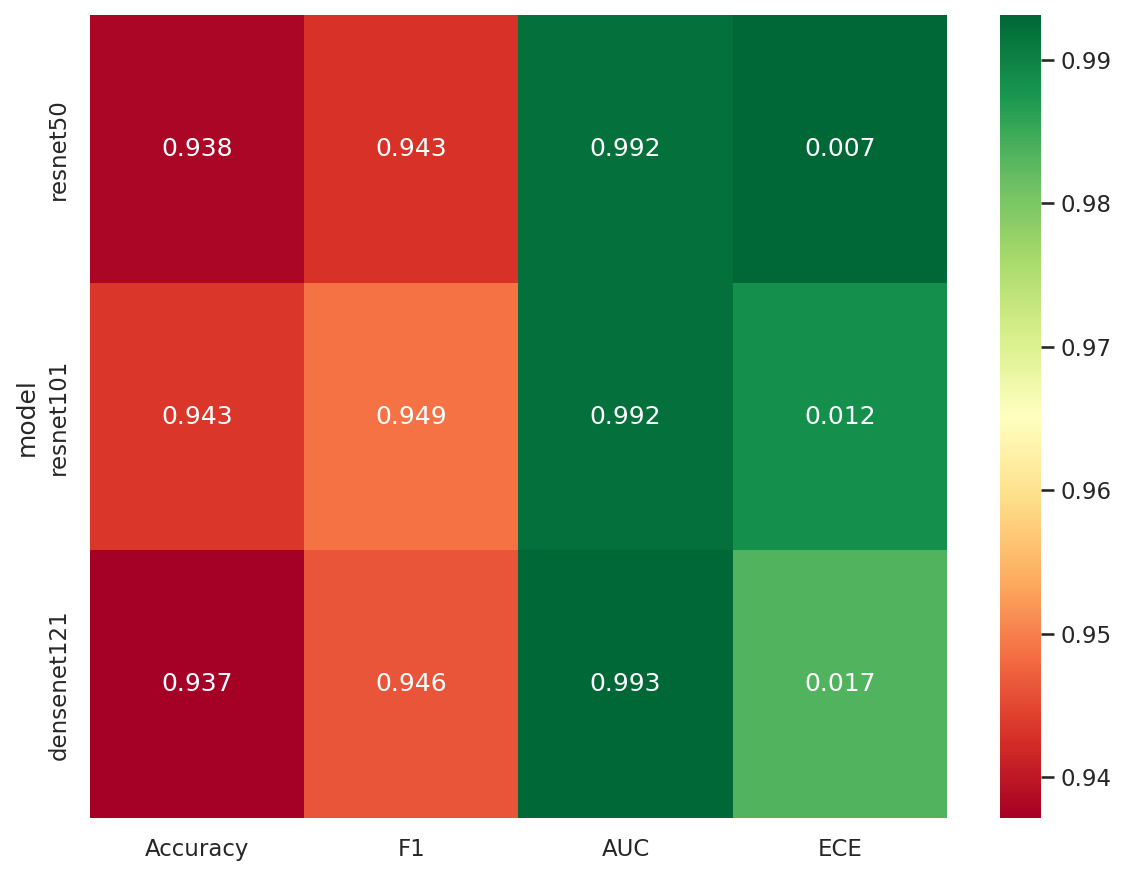

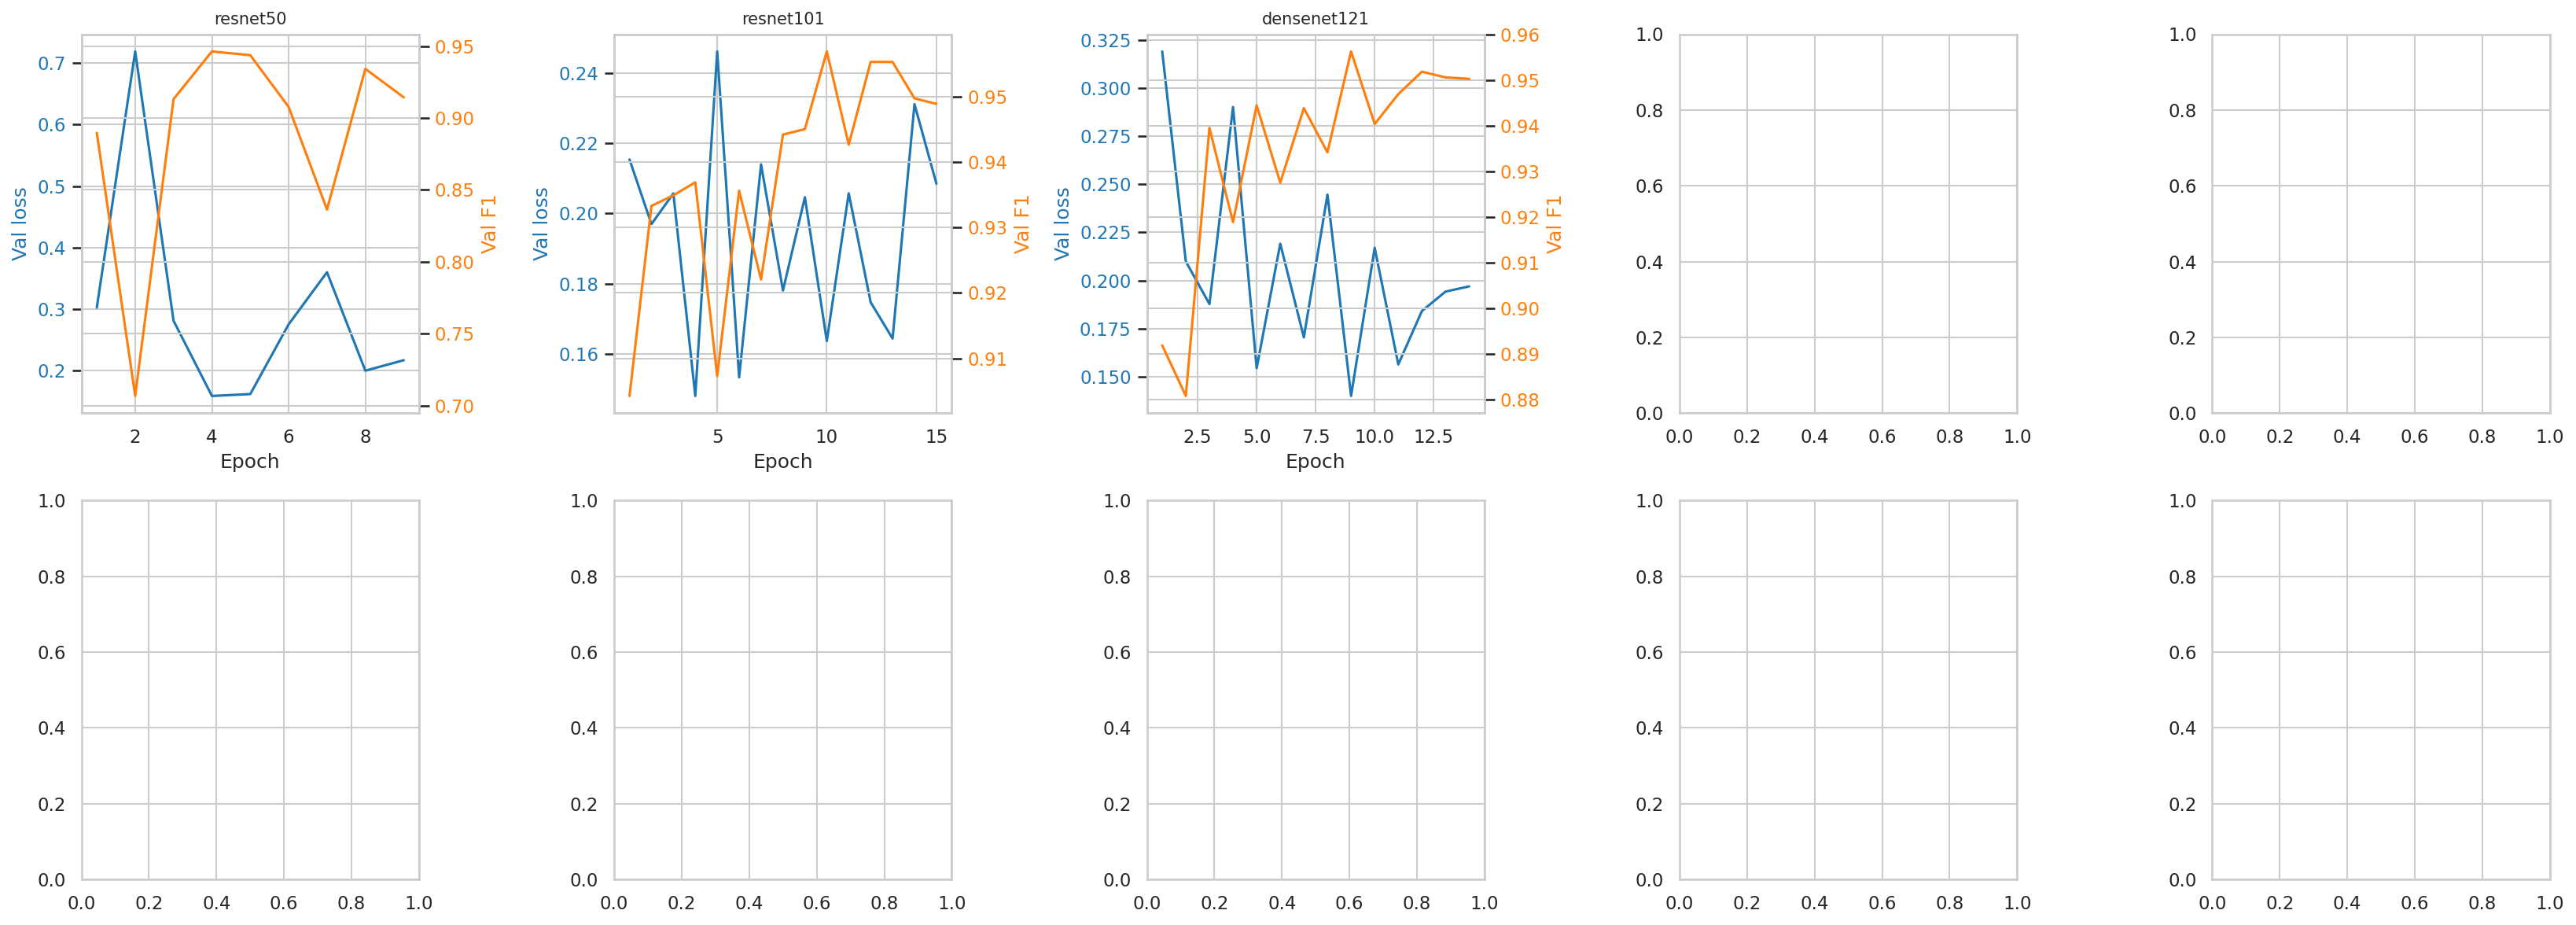

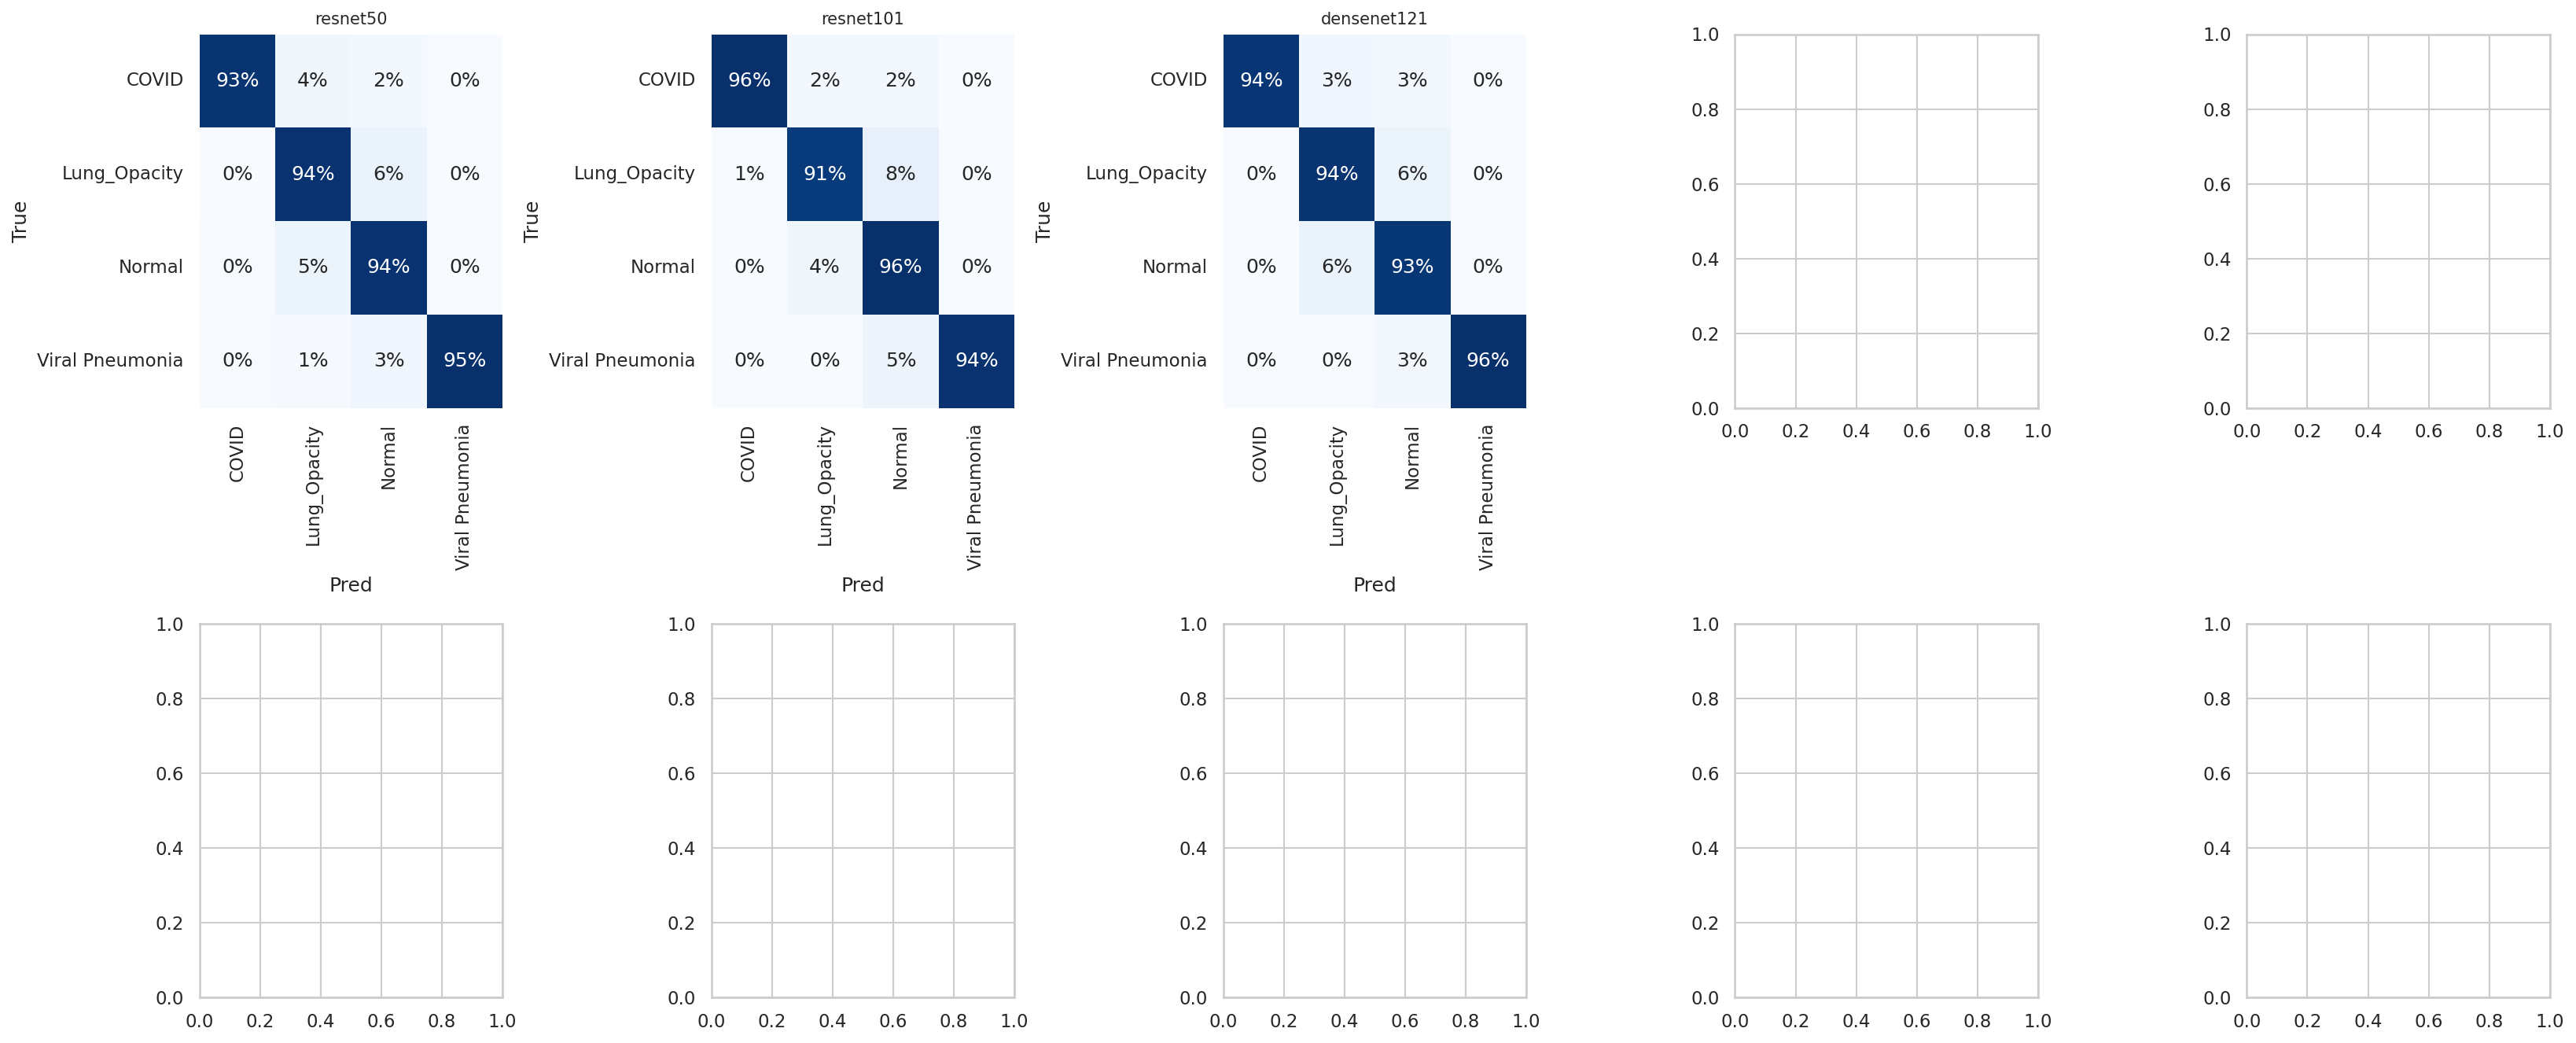

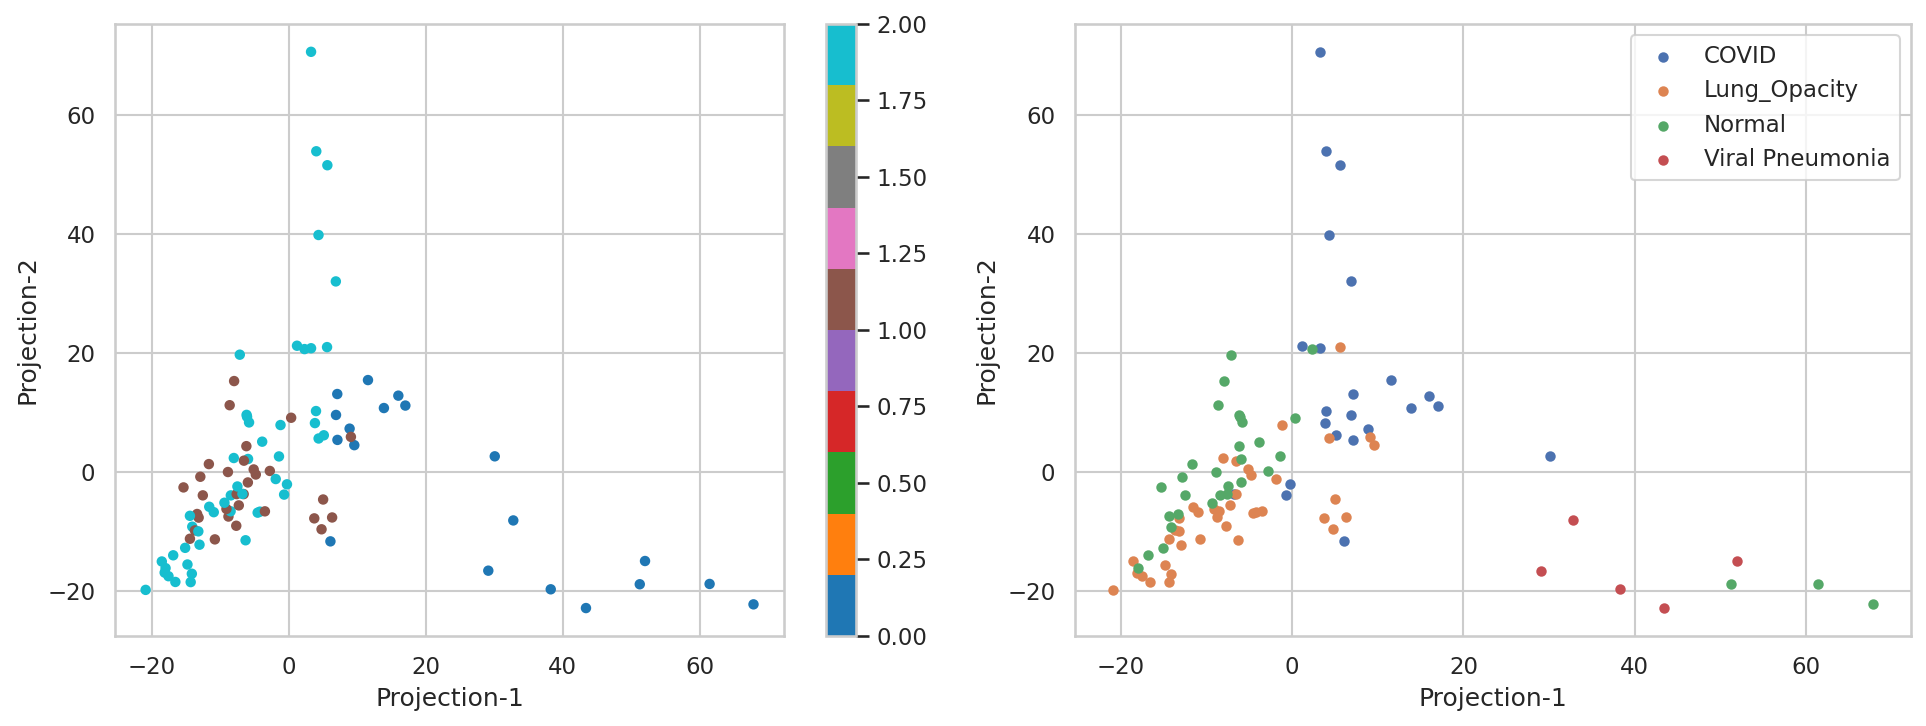

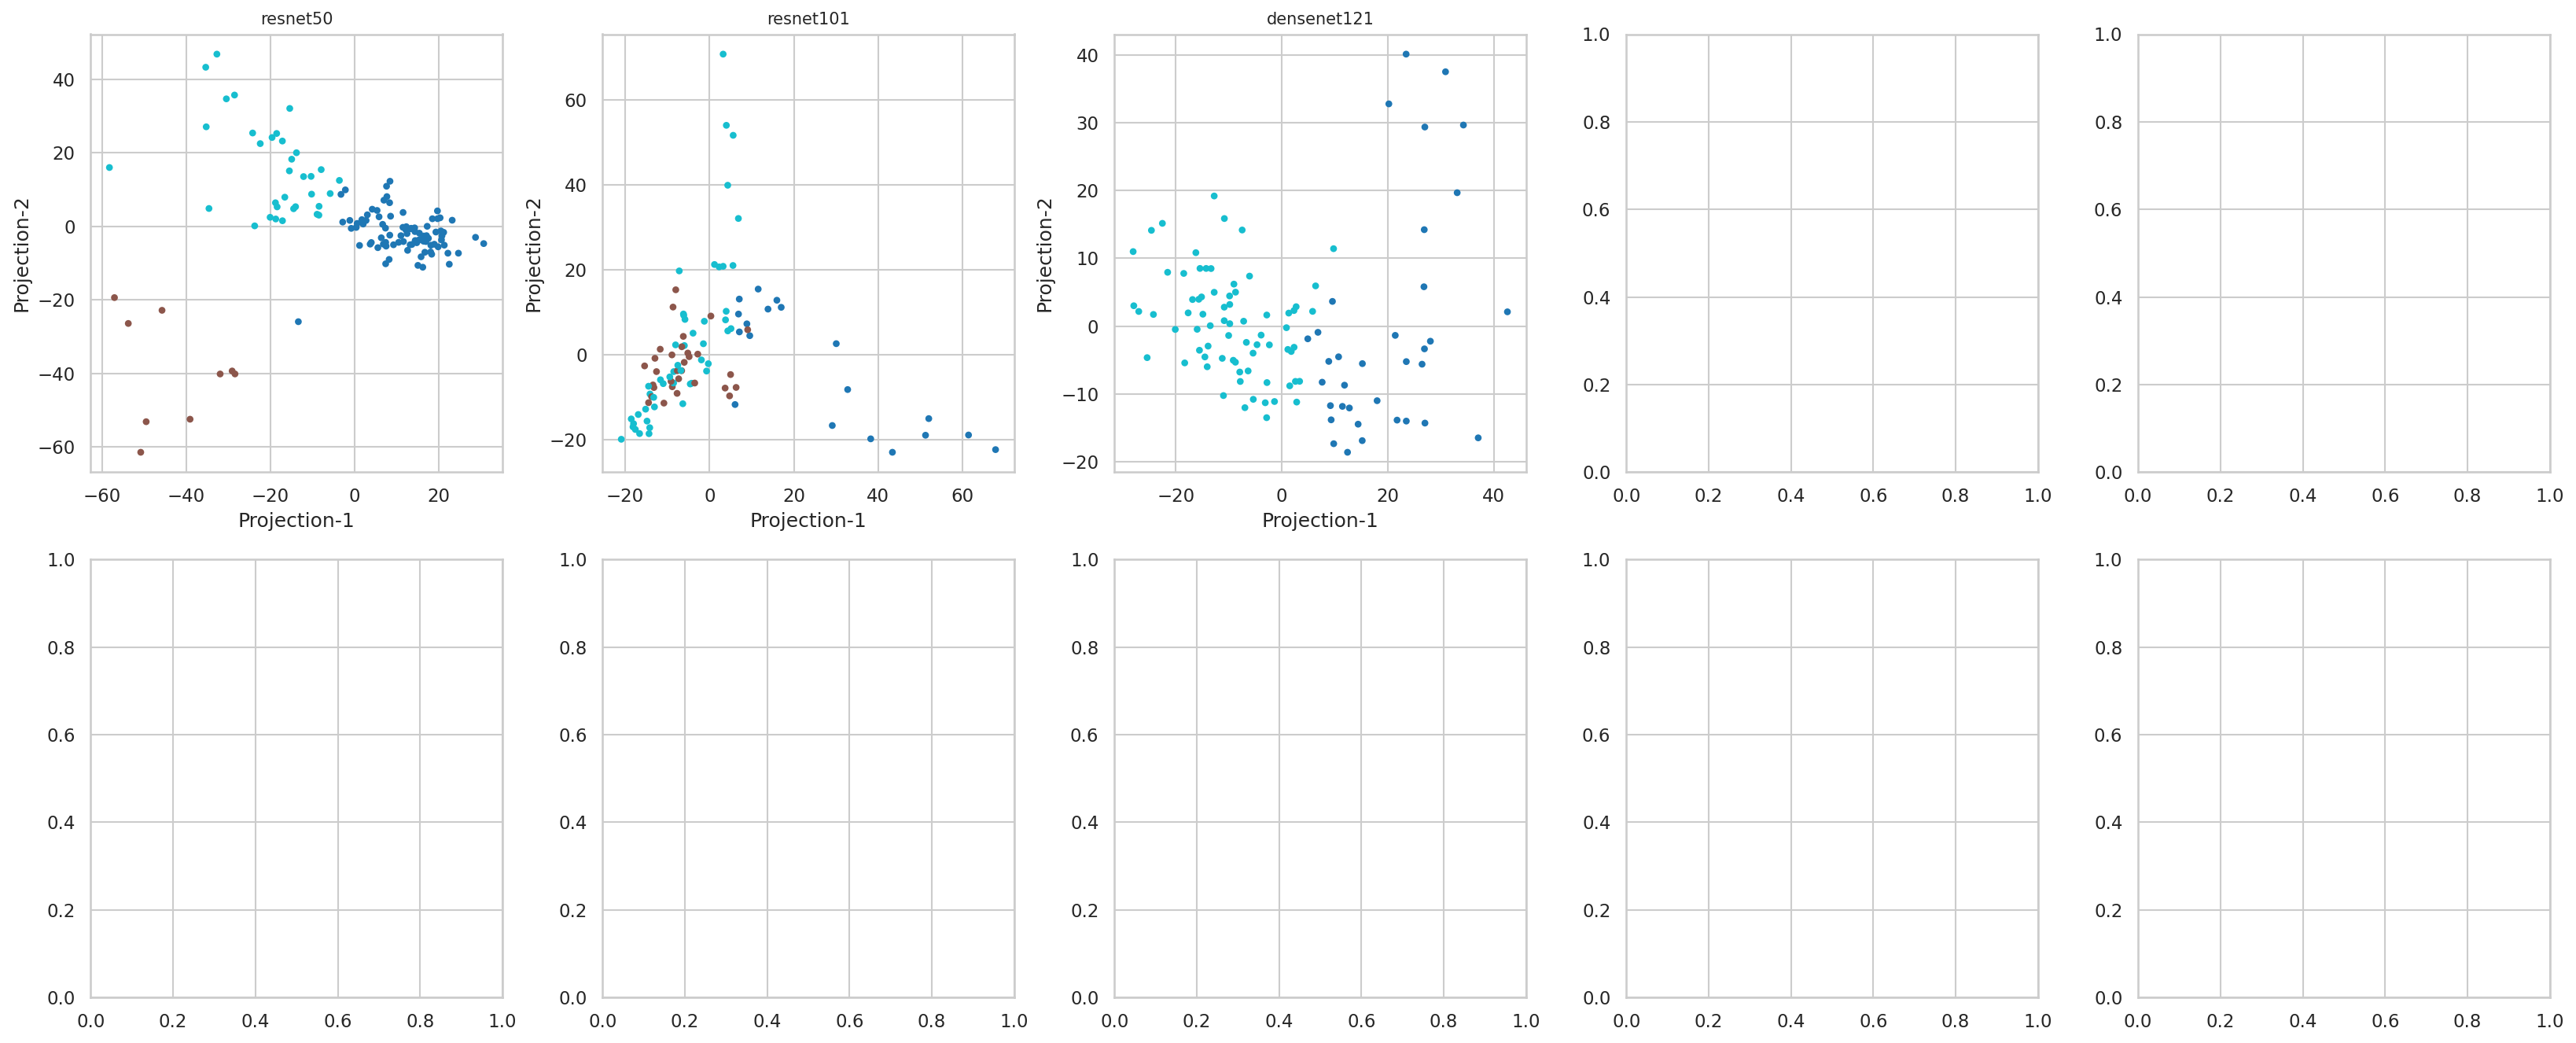

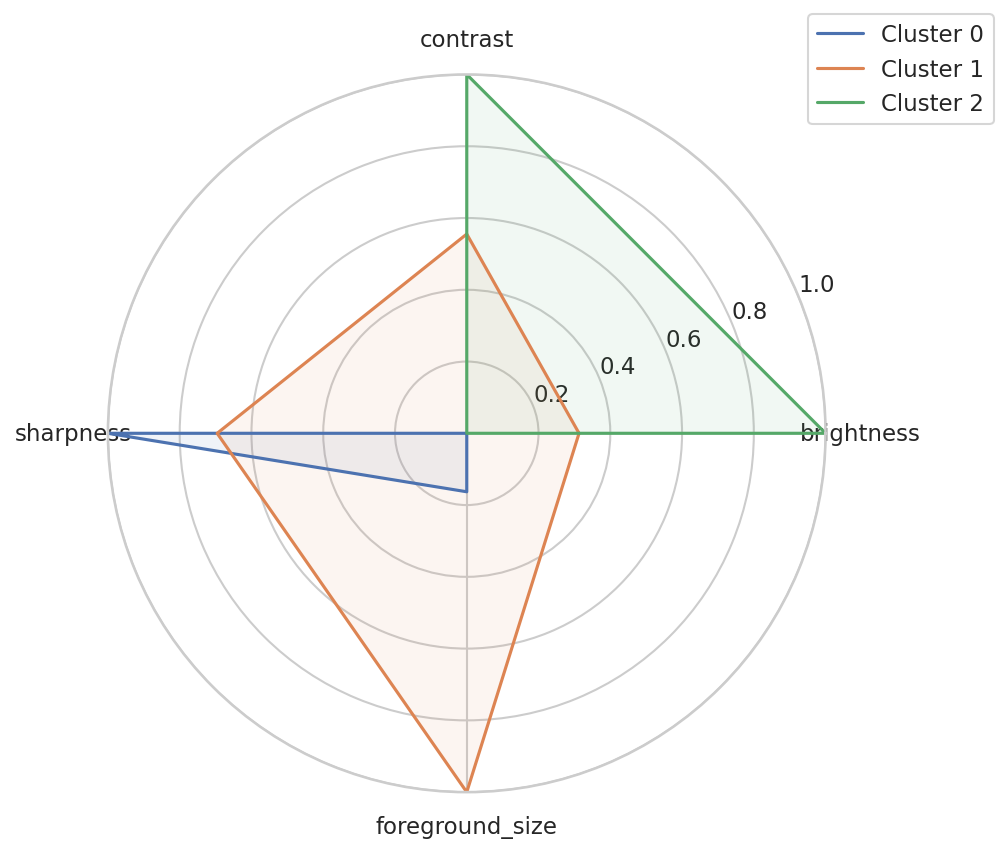

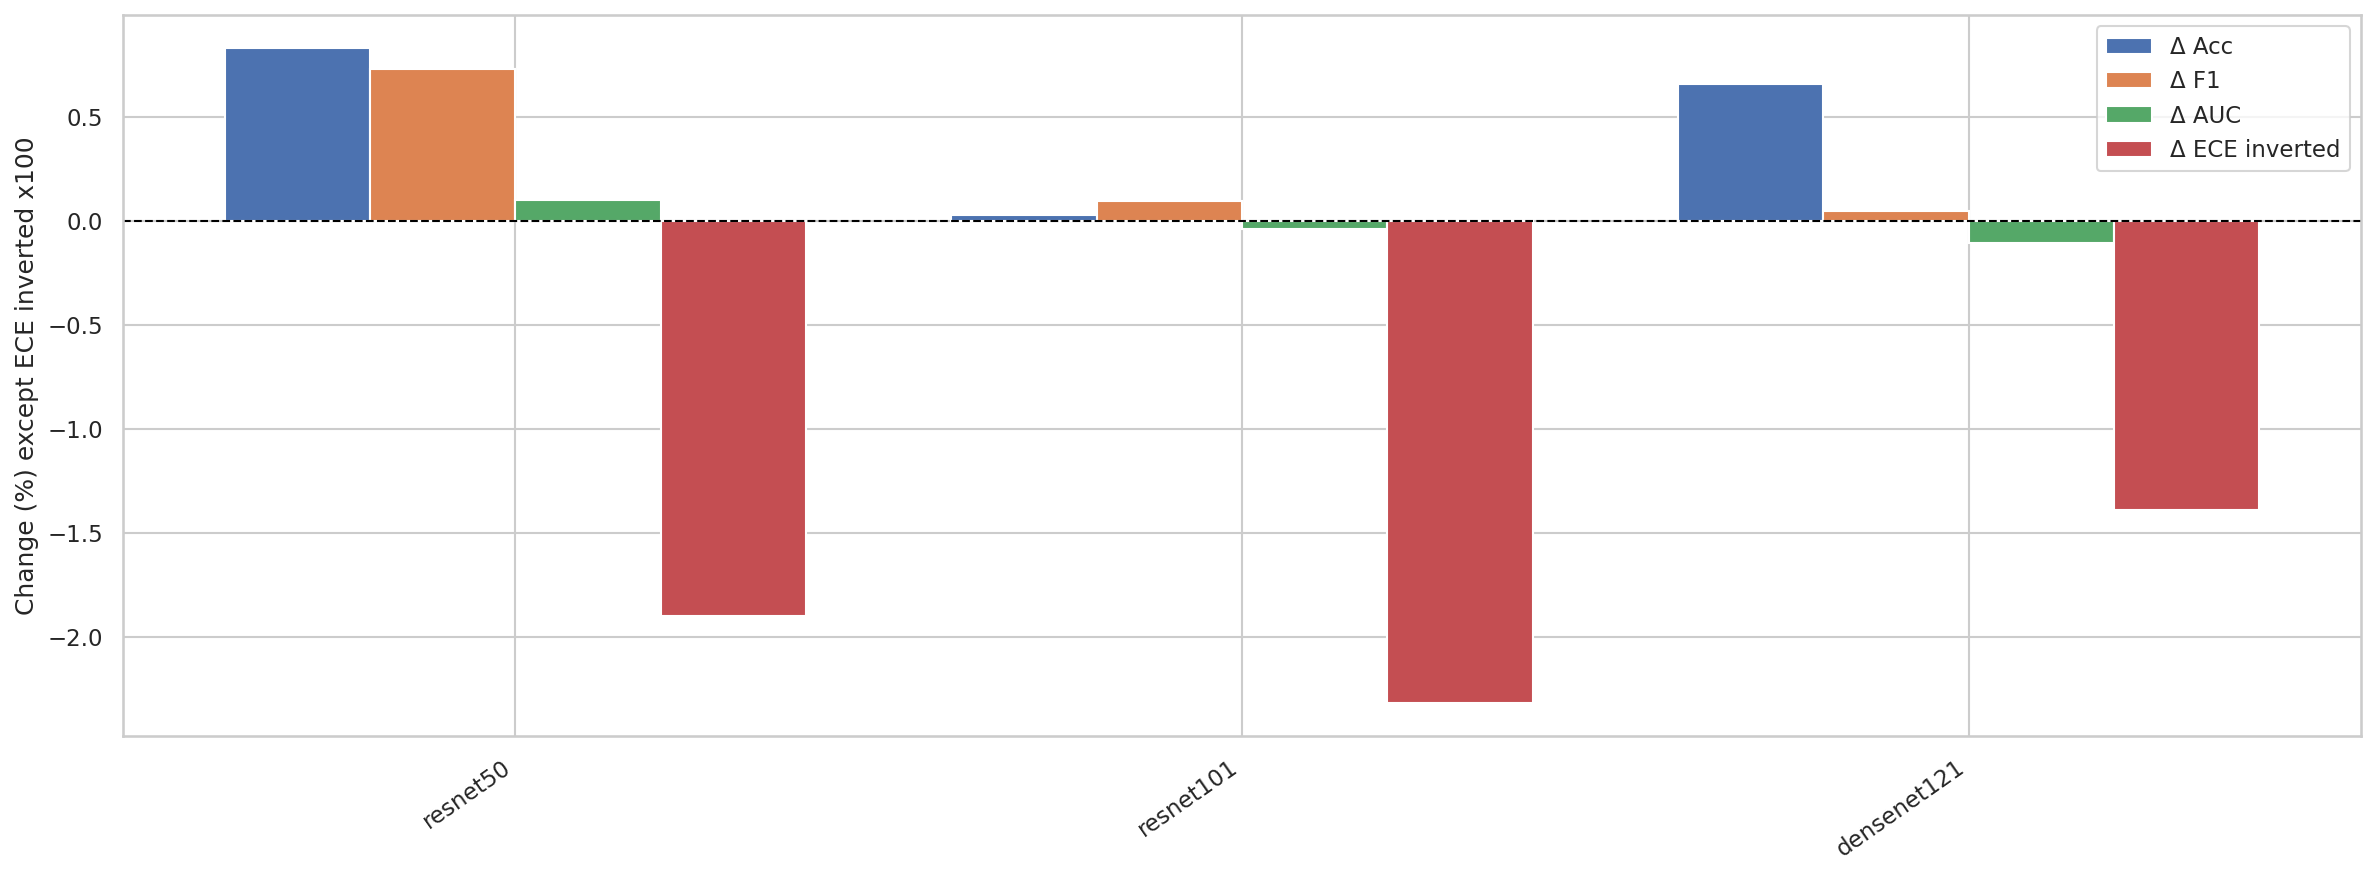

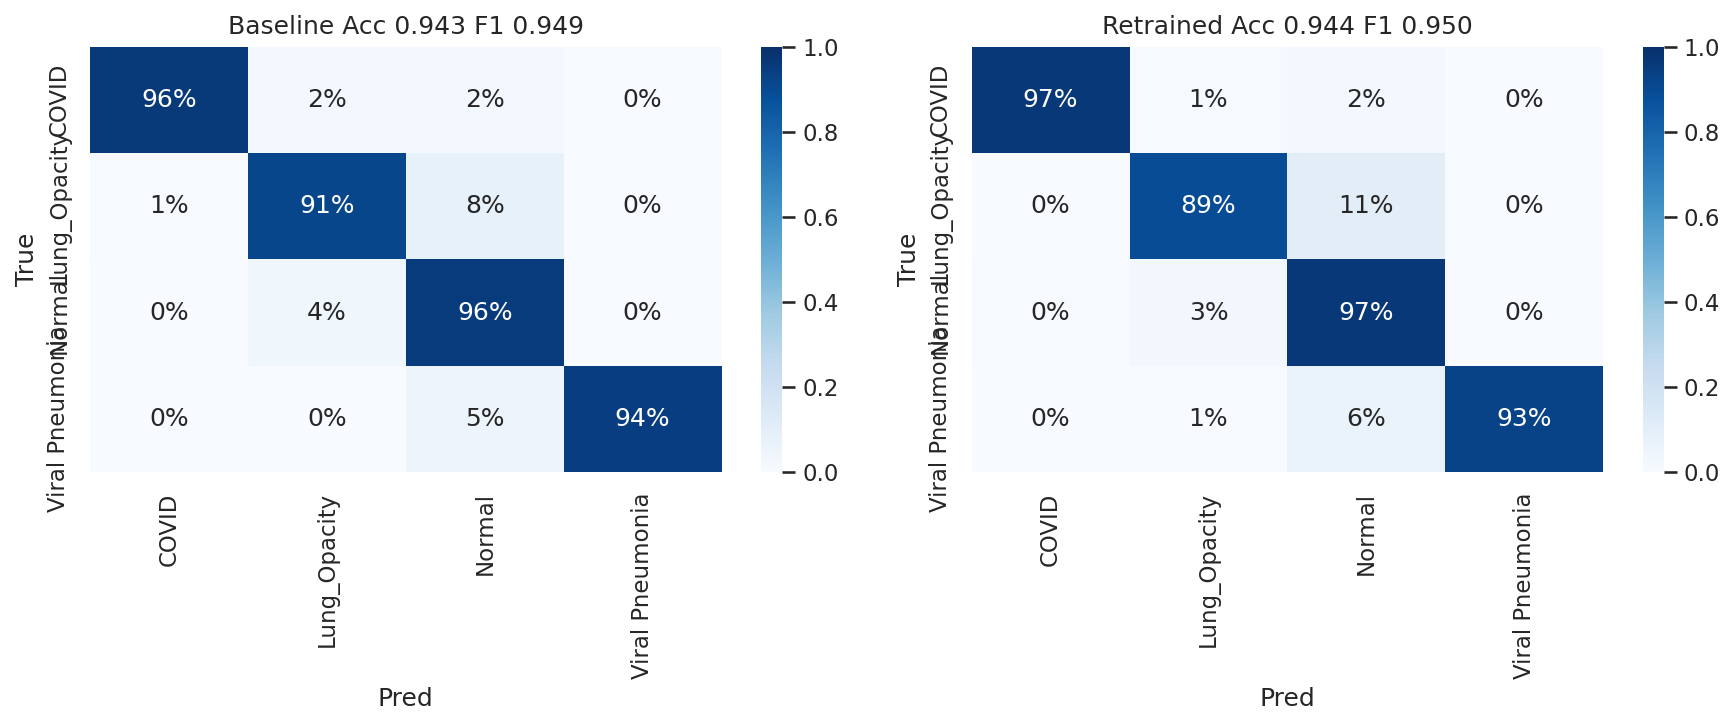

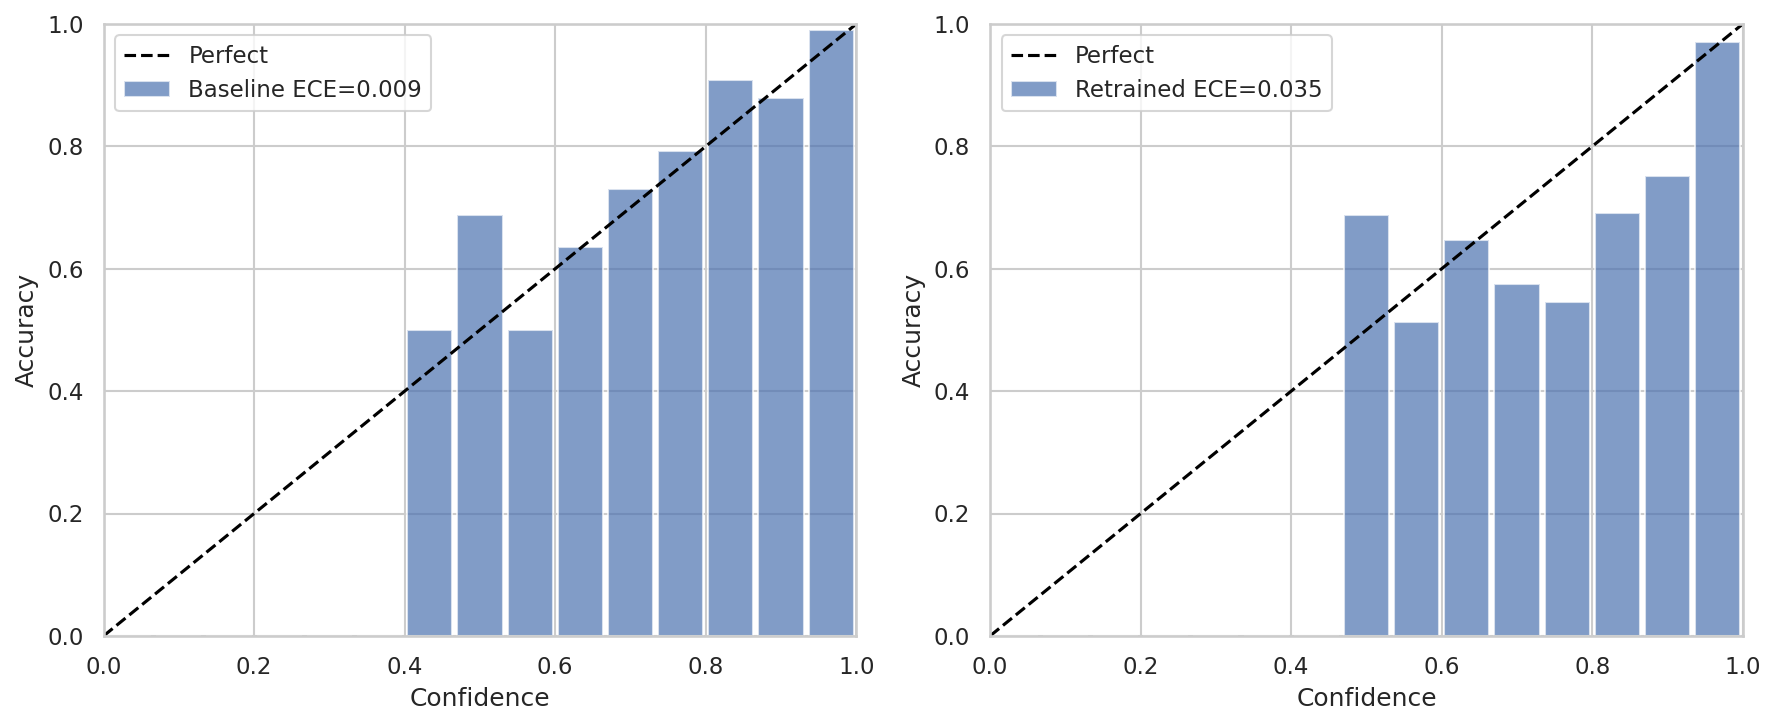

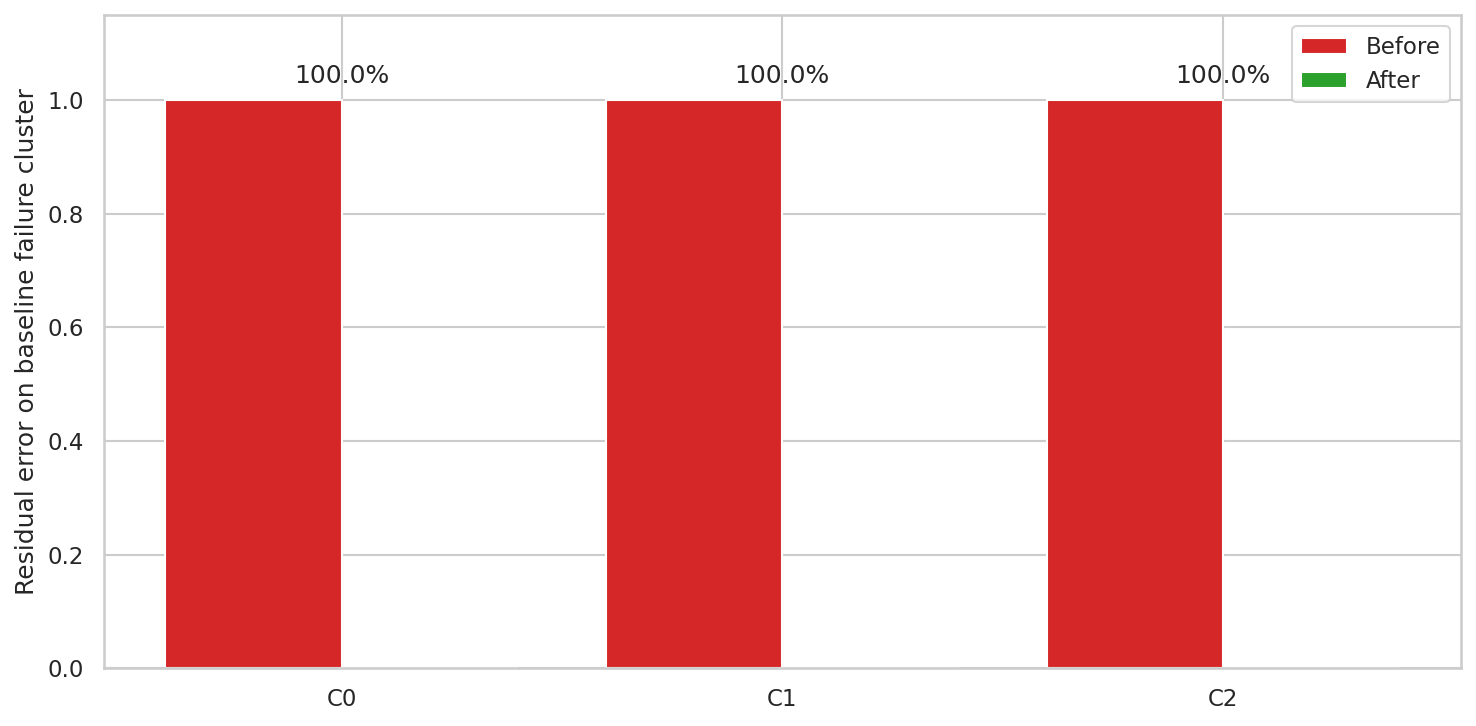

✓ Section 11 complete


In [15]:
def reliability_bins(probs, labels, n_bins=15):
    """Return per-bin confidence and accuracy for reliability diagrams."""
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


if len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"Best model selected for detailed figures: {best_model}")


# Figure 1 — Baseline performance heatmap
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].rename(
    columns={
        'test_accuracy': 'Accuracy',
        'test_f1': 'F1',
        'test_auc': 'AUC',
        'test_ece': 'ECE'
    }
)

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df,
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True
)
plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 2 — Training curves
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})

    if len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)

    ax.plot(epochs, hist['val_loss'], color='tab:blue')
    ax.set_ylabel('Val loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig2_training_curves.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 3 — Baseline confusion matrices
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue

    cm = baseline_confusions[model_name]
    cmn = np.divide(
        cm,
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0
    )

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 4 — Projection plots for best model
best_clustered = all_clustered[best_model]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

sc = axes[0].scatter(
    best_clustered['umap_x'],
    best_clustered['umap_y'],
    c=best_clustered['cluster'],
    cmap='tab10',
    s=16
)
axes[0].set_xlabel('Projection-1')
axes[0].set_ylabel('Projection-2')
fig.colorbar(sc, ax=axes[0])

for label_id, name in enumerate(CONFIG['class_names']):
    sub = best_clustered[best_clustered['true_label'] == label_id]
    axes[1].scatter(
        sub['umap_x'],
        sub['umap_y'],
        s=16,
        label=name
    )

axes[1].set_xlabel('Projection-1')
axes[1].set_ylabel('Projection-2')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig4_projection_best_model.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 5 — Projection plots for all models
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue

    cdf = all_clustered[model_name]

    ax.scatter(
        cdf['umap_x'],
        cdf['umap_y'],
        c=cdf['cluster'],
        cmap='tab10',
        s=10
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Projection-1')
    ax.set_ylabel('Projection-2')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig5_projection_all_models.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 6 — Cluster profile radar chart
profile_df = all_profiles[best_model]

if len(profile_df) > 0:
    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()

        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['brightness', 'contrast', 'sharpness', 'foreground_size'])
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig6_cluster_radar.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print(f"Skipping Figure 6: no cluster profile rows for {best_model}")


# Figure 7 — Improvement bar chart
if len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc'),
        ('delta_f1_pct', 'Δ F1'),
        ('delta_auc_pct', 'Δ AUC'),
        ('delta_ece', 'Δ ECE inverted')
    ]

    for i, (col, label) in enumerate(metrics):
        vals = (
            -100 * improvement_df[col].values
            if col == 'delta_ece'
            else improvement_df[col].values
        )

        ax.bar(
            x + (i - 1.5) * width,
            vals,
            width,
            label=label
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Change (%) except ECE inverted x100')
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig7_improvement_bars.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 7: improvement_df is empty")


# Figure 8 — Before vs after confusion matrices
if len(improvement_df) > 0 and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0]

    plot_items = [
        (
            axes[0],
            baseline_confusions[best_model],
            f"Baseline Acc {base_row['test_accuracy']:.3f} F1 {base_row['test_f1']:.3f}"
        ),
        (
            axes[1],
            retrained_confusions[best_model],
            f"Retrained Acc {ret_row['retrained_acc']:.3f} F1 {ret_row['retrained_f1']:.3f}"
        )
    ]

    for ax, cm, label in plot_items:
        cmn = np.divide(
            cm,
            cm.sum(axis=1, keepdims=True),
            out=np.zeros_like(cm, dtype=float),
            where=cm.sum(axis=1, keepdims=True) != 0
        )

        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            vmin=0,
            vmax=1
        )

        ax.set_title(label)
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 8: retrained results unavailable")


# Figure 9 — Reliability diagrams
if len(improvement_df) > 0 and best_model in retrained_predictions:
    base_pred = all_predictions[best_model]
    base_probs = np.stack(
        base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
    )
    base_labels = base_pred['true_label'].values

    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    plot_items = [
        (
            axes[0],
            base_probs,
            base_labels,
            f"Baseline ECE={compute_ece(base_probs, base_labels):.3f}"
        ),
        (
            axes[1],
            ret_probs,
            ret_labels,
            f"Retrained ECE={compute_ece(ret_probs, ret_labels):.3f}"
        )
    ]

    for ax, probs, labels, caption in plot_items:
        centers, bacc, bconf, counts = reliability_bins(
            probs,
            labels,
            CONFIG['ece_bins']
        )

        ax.bar(
            centers,
            bacc,
            width=1 / CONFIG['ece_bins'] * 0.9,
            alpha=0.7,
            label=caption
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='black',
            label='Perfect'
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig9_ece_reliability.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 9: retrained probability outputs unavailable")


# Figure 10 — Cluster residual error reduction
if len(improvement_df) > 0 and best_model in retrained_predictions:
    clustered = all_clustered[best_model]

    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    before_rates, after_rates = [], []
    clusters = sorted(clustered['cluster'].unique())

    for c in clusters:
        before_rates.append(1.0)

        sub = ret_clustered[ret_clustered['cluster'] == c]

        after_rates.append(
            float((sub['true_label'] != sub['pred_label']).mean())
            if len(sub)
            else 0
        )

    x = np.arange(len(clusters))

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    ax.bar(
        x - 0.2,
        before_rates,
        0.4,
        color='tab:red',
        label='Before'
    )

    ax.bar(
        x + 0.2,
        after_rates,
        0.4,
        color='tab:green',
        label='After'
    )

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(
            i,
            max(b, a) + 0.03,
            f"{(b - a) * 100:.1f}%",
            ha='center'
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Residual error on baseline failure cluster')
    ax.set_ylim(0, 1.15)
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 10: retrained predictions unavailable")

print("✓ Section 11 complete")


In [16]:
def pretty_model_name(name: str) -> str:
    """Convert internal model ID to human-readable display name."""
    return {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }.get(name, name)


# ── Initialize markdown summary lines ─────────────────────────────
summary_lines = []

# ── Improvement table (if available) ─────────────────────────────
if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base→ret) | F1 (base→ret) | "
        "AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}→{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}→{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}→{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}→{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append("Retraining evaluation is unavailable — no improvement data.")
    summary_lines.append("Ensure `improvement_df` was generated during retraining.")


# ── Best baseline model ──────────────────────────────────────────
best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values('test_f1', ascending=False).iloc[0]

if best_baseline is not None:
    final_best_baseline = (
        f"- Best performing baseline model: "
        f"{pretty_model_name(best_baseline['model'])} "
        f"(F1={best_baseline['test_f1']:.3f}, "
        f"Acc={best_baseline['test_accuracy']:.3f}, "
        f"AUC={best_baseline['test_auc']:.3f}, "
        f"ECE={best_baseline['test_ece']:.3f})"
    )
else:
    final_best_baseline = "- Best performing baseline model: unavailable"


# ── Most improved model after retraining ──────────────────────────
most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values('delta_f1_pct', ascending=False).iloc[0]

if most_improved is not None:
    final_most_improved = (
        f"- Most improved model after retraining: "
        f"{pretty_model_name(most_improved['model'])} "
        f"(Δ F1={most_improved['delta_f1_pct']:+.1f}%, "
        f"final F1={most_improved['retrained_f1']:.3f})"
    )
else:
    final_most_improved = "- Most improved model after retraining: unavailable"


# ── Dominant failure pattern across models ─────────────────────────
all_failure_pairs = []
for df in all_failures.values():
    if len(df) > 0:
        all_failure_pairs.extend(list(zip(df['true_label'], df['pred_label'])))

if all_failure_pairs:
    dominant_true, dominant_pred = Counter(all_failure_pairs).most_common(1)[0][0]
    dominant_text = (
        f"{CONFIG['class_names'][dominant_true]} → {CONFIG['class_names'][dominant_pred]}"
    )
else:
    dominant_text = "No consistent misclassification pattern detected"


# ── Clinical/Operational Recommendation (adapted for radiography) ─
clinical_recommendation = (
    "Use the retrained best-performing model only as a triage or decision-support tool, "
    "not for autonomous diagnosis. Deploy with continuous calibration monitoring, "
    "subgroup and failure-cluster audits, radiologist review, and prospective validation "
    "on local hospital data before any clinical deployment. "
    "Particularly monitor confusion between 'Viral Pneumonia' and 'COVID' as a potential risk zone."
)


# ── Final Text Assembly ────────────────────────────────────────────
final_text = "\n".join(summary_lines) + "\n\n"
final_text += final_best_baseline + "\n"
final_text += final_most_improved + "\n"
final_text += "- Dataset: COVID-19 Radiography 4-class experiment\n"
final_text += f"- Dataset-level dominant failure pattern: {dominant_text}\n"
final_text += f"- Recommendation for clinical use: {clinical_recommendation}\n\n"
final_text += "This report synthesizes performance, improvement, and failure analysis "
final_text += "across all models. See figures/ and results/ for visual and tabular details."

# ── Save to file ──────────────────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_COVID.md'
summary_path.write_text(final_text)

print("\n" + final_text)
print(f"Saved final summary to: {summary_path}")
print("✓ Section 12 complete")


| Model | Family | Acc (base→ret) | F1 (base→ret) | AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ResNet-50 | CNN | 0.938→0.946 | 0.943→0.950 | 0.992→0.993 | 0.007→0.026 | +0.8% | Selective |
| ResNet-101 | CNN | 0.943→0.944 | 0.949→0.950 | 0.992→0.992 | 0.012→0.035 | +0.0% | Selective |
| DenseNet-121 | CNN | 0.937→0.943 | 0.946→0.947 | 0.993→0.992 | 0.017→0.031 | +0.7% | Selective |

- Best performing baseline model: ResNet-101 (F1=0.949, Acc=0.943, AUC=0.992, ECE=0.012)
- Most improved model after retraining: ResNet-50 (Δ F1=+0.7%, final F1=0.950)
- Dataset: COVID-19 Radiography 4-class experiment
- Dataset-level dominant failure pattern: Normal → Lung_Opacity
- Recommendation for clinical use: Use the retrained best-performing model only as a triage or decision-support tool, not for autonomous diagnosis. Deploy with continuous calibration monitoring, subgroup and failure-cluster audits, radiologist review, and prospective validatio

In [17]:
# FINAL: Save cross-notebook compatible results
DATASET_NAME = 'covid'
DATASET_DISPLAY = 'COVID-19 Radiography'

print(f"Saving cross-notebook results for {DATASET_DISPLAY}...")

# Ensure output directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ── 1. Improvement results (retrained vs baseline) ──────────────────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  Saved improvement results: {len(improvement_df_export)} rows → {out_path}")
else:
    print("  Warning: improvement_df not found or empty — skipping improvement export")

# ── 2. Untargeted control results ───────────────────────────────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  Saved untargeted control: {len(untargeted_df_export)} rows → {out_path}")
else:
    print("  Warning: untargeted_df not found or empty — skipping untargeted control export")

# ── 3. Cluster summary (from failure clustering) ───────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        if model_name not in all_failures:
            n_failures = 0
        else:
            n_failures = len(all_failures[model_name])

        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  Saved cluster summaries: {len(cluster_summary_df)} rows → {out_path}")
else:
    print("  Warning: No clustering summaries available — skipping cluster export")

# ── 4. Temperature scaling results ──────────────────────────────────
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  Saved temperature scaling: {len(temp_export)} rows → {out_path}")
    else:
        missing = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  Warning: Missing temperature columns: {missing} — skipping temp export")
else:
    print("  Warning: baseline_df not available — skipping temperature scaling export")

# ── Summary of saved files ──────────────────────────────────────────
print(f"\n✅ Cross-notebook results saved for dataset='{DATASET_NAME}'")
print(f"   Use these files for aggregation, comparison, and plotting across datasets.")

Saving cross-notebook results for COVID-19 Radiography...
  Saved improvement results: 3 rows → /kaggle/working/results/improvement_covid.csv
  Saved untargeted control: 3 rows → /kaggle/working/results/untargeted_control_covid.csv
  Saved cluster summaries: 3 rows → /kaggle/working/results/cluster_summary_covid.csv
  Saved temperature scaling: 3 rows → /kaggle/working/results/temperature_scaling_covid.csv

✅ Cross-notebook results saved for dataset='covid'
   Use these files for aggregation, comparison, and plotting across datasets.
